# Why Do Customers Leave? Identifying Churn Drivers in Telecom
## A Data Analyst Portfolio Project
### Framework: 6-Step Problem-Solving + Pyramid Principle

**Author:** Reinaldi Santoso

**Date:** Maret 2026

**Dataset:** IBM Telco Customer Churn — *"Why Do Customers Leave? Can You Spot the Churners?"* (Kaggle — hassanelfattmi)

**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly · SciPy · Power BI (export-ready)

**Repository:** https://github.com/Reinaldis/Telco-Churn-Data-Analysis-Portfolio

---

### Executive Summary
> **Bottom Line:** Dari 7,043 pelanggan telco yang dianalisis, **churn rate sebesar 26.5%** (1,869 pelanggan) —
> mengakibatkan revenue leakage sebesar **\$3,684,460** (17.2% dari total revenue \$21.4M).
> Tiga faktor yang paling kuat berasosiasi dengan churn adalah:
> (1) **Satisfaction score** (r = −0.755), (2) **Contract type** — Month-to-Month churn 45.8% vs yearly 6.2%,
> dan (3) **Tenure** — 47.4% churn di ≤12 bulan pertama vs 17.1% setelahnya.
>
> Segmen prioritas tertinggi: **1,947 pelanggan High Value / High Risk** dengan churn rate 57.9%
> dan revenue at risk **\$2.9M**. Rekomendasi utama: migrasi kontrak, service bundling Fiber Optic,
> dan onboarding redesign untuk 12 bulan pertama.

### Methodology Note
> Analisis ini bersifat **descriptive dan diagnostic** — bertujuan memahami pola dan faktor
> yang berasosiasi dengan churn, bukan memprediksi churn individual. Korelasi yang ditemukan
> belum tentu menunjukkan kausalitas. Dataset ini memiliki 6 tabel relasional yang di-merge
> menjadi satu master table (7,043 rows × 60 cols) melalui `customer_id`.
> Semua 5 hipotesis yang diuji **terkonfirmasi secara statistik** (p < 0.05).

---

### Daftar Isi
0. Project Identity & Executive Summary
1. Problem Framing (Define → Dissect → Prioritize → Work Plan)
2. Environment Setup & Data Loading
3. Data Quality Assessment, Merge & Cleaning
4. Exploratory Data Analysis (6 Blok Analisis + Churn Reasons)
5. Customer Segmentation & Value Analysis
6. Churn Risk Profiling & Early Warning
7. Synthesis & Recommendations (Pyramid Principle Full)
8. Export untuk Power BI

---
# SECTION 1 — PROBLEM FRAMING
## 6-Step: DEFINE → DISSECT → PRIORITIZE → WORK PLAN

---

## 1.1 Define the Problem

**Core Business Problem (satu kalimat presisi):**
Perusahaan telekomunikasi ini kehilangan ~26% pelanggan (churned) tanpa strategi retention yang tersegmentasi — sehingga tidak mampu mengalokasikan budget retention secara efisien ke segmen yang paling berdampak.

**Problem Statement — Who, What, Why:**
| Dimensi | Detail |
|---------|--------|
| **Who** | Tim Revenue Operations & Customer Success yang bertanggung jawab atas Net Revenue Retention |
| **What** | Churn terjadi di berbagai segmen dengan pola yang belum dipetakan. Strategi retention masih bersifat generik (one-size-fits-all) |
| **Why it matters** | Customer Acquisition Cost (CAC) di industri telco rata-rata 5–7× lebih mahal dari biaya retention. Tanpa pemahaman granular tentang churn drivers, budget tidak dialokasikan secara efisien |

**Success Criteria — analisis ini berhasil jika menjawab:**
1. Berapa churn rate aktual, dan segmen mana yang paling terdampak?
2. Apa 5 faktor yang paling kuat berasosiasi dengan churn?
3. Segmen pelanggan mana yang menjadi prioritas retention berdasarkan kombinasi risk × value?

## 1.2 Dissect the Problem — Logic Tree (MECE)

```
CHURN DRIVERS (berdasarkan variabel yang tersedia)
│
├── A. SERVICE EXPERIENCE
│   ├── A1. Internet type (Fiber Optic vs DSL vs Cable)
│   ├── A2. Value-added services (OnlineSecurity, TechSupport, dll.)
│   ├── A3. Service bundling level (berapa banyak layanan aktif?)
│   └── A4. Data usage & unlimited data plan
│
├── B. COMMERCIAL / CONTRACTUAL
│   ├── B1. Contract type (Month-to-Month vs 1yr vs 2yr)
│   ├── B2. Pricing level (monthly charges tier)
│   ├── B3. Payment method (Electronic check vs auto-payment)
│   ├── B4. Billing preference (Paperless vs traditional)
│   └── B5. Promotional offer (Offer A–E vs None)
│
├── C. CUSTOMER LIFECYCLE
│   ├── C1. Tenure length (kapan paling rentan churn?)
│   ├── C2. CLTV (Customer Lifetime Value)
│   └── C3. Referral behavior (referred_a_friend, number_of_referrals)
│
├── D. SATISFACTION & SENTIMENT
│   ├── D1. Satisfaction score (1–5)
│   ├── D2. Churn category (Competitor, Price, Dissatisfaction, Attitude, Other)
│   └── D3. Churn reason (granular)
│
└── E. DEMOGRAPHICS
    ├── E1. Age & senior citizen status
    ├── E2. Marital status & dependents
    └── E3. Gender (expected: not significant)
```

**Catatan:** Dataset ini sangat kaya — mencakup satisfaction score, explicit churn reasons, dan CLTV. Ini memungkinkan analisis diagnostic yang lebih dalam dibanding dataset telco pada umumnya.

## 1.3 Prioritize — Hypotheses to Test

Berdasarkan logic tree dan literatur telco churn, hipotesis berikut diprioritaskan:

| ID | Hipotesis | Variable | Expected Direction |
|----|-----------|----------|-------------------|
| **H1** | Pelanggan month-to-month memiliki churn rate ≥2× pelanggan kontrak tahunan | `contract` | M2M >> Yearly |
| **H2** | Pelanggan tanpa TechSupport & OnlineSecurity memiliki churn rate jauh lebih tinggi | `premium_tech_support`, `online_security` | No >> Yes |
| **H3** | Churn terkonsentrasi di pelanggan dengan tenure < 12 bulan | `tenure` | Early = high risk |
| **H4** | Pelanggan Fiber Optic memiliki churn rate lebih tinggi dibanding DSL/Cable | `internet_type` | Fiber > DSL/Cable |
| **H5** | Pelanggan Electronic Check memiliki churn rate lebih tinggi dari auto-payment | `payment_method` | E-check > auto |

**80/20 Rule:** Fokus analisis pada H1–H3 terlebih dahulu (contract, services, tenure) karena ini adalah lever yang paling actionable oleh tim retention.

## 1.4 Analysis Work Plan

| Section | Pertanyaan Bisnis | Output |
|---------|------------------|--------|
| **Sec 3** | Apakah data siap dianalisis? | `df_master` (1 baris = 1 customer) |
| **Sec 4.1** | Berapa churn rate & segmen mana terdampak? | KPI dashboard |
| **Sec 4.2** | Kapan dalam lifecycle churn paling terjadi? (H3) | Tenure analysis + survival curve |
| **Sec 4.3** | Berapa revenue yang hilang akibat churn? | Revenue impact quantification |
| **Sec 4.4** | Layanan apa yang "melindungi" dari churn? (H2, H4) | Service adoption analysis |
| **Sec 4.5** | Apakah contract & payment berpengaruh? (H1, H5) | Contract & payment analysis |
| **Sec 4.6** | Variabel mana paling prediktif? | Correlation ranking + heatmap |
| **Sec 5** | Siapa high-value churner? | 2×2 Value × Risk matrix |
| **Sec 6** | Apa profil pelanggan paling berisiko? | Risk scoring + churn reasons |
| **Sec 7** | Apa rekomendasi untuk leadership? | Pyramid synthesis + action plan |
| **Sec 8** | Data siap untuk Power BI? | Clean CSV + JSON exports |

---
# SECTION 2 — ENVIRONMENT SETUP & DATA LOADING
## Persiapan sebelum analisis dimulai

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.1 IMPORT LIBRARIES
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization — Static
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Visualization — Interactive
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical Testing
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu

# Utilities
import os
import json
from datetime import datetime

# Display Settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot Theme — konsisten sepanjang notebook ──
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'churn': '#E74C3C',      # merah — selalu untuk churn
    'retain': '#27AE60',     # hijau — selalu untuk retained
    'neutral': '#2980B9',    # biru — netral
    'warning': '#F39C12',    # kuning — warning
    'dark': '#2C3E50',       # dark — text/accent
    'light_bg': '#F8F9FA',   # background
    'joined': '#8E44AD'      # ungu — untuk pelanggan baru
}
PAL = ['#2980B9', '#27AE60', '#F39C12', '#E74C3C', '#8E44AD', '#1ABC9C']

print("✓ Environment ready")
print(f"  Pandas {pd.__version__} | NumPy {np.__version__}")
print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ Environment ready
  Pandas 2.2.2 | NumPy 2.0.2
  Timestamp: 2026-03-26 01:42


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.1b UPLOAD FILES (untuk Google Colab)
# ═══════════════════════════════════════════════════════════════
# Jalankan cell ini jika menggunakan Google Colab
# Upload semua 6 file CSV ke /content/

from google.colab import files
import os

# Cek apakah file sudah ada
required_files = ['Customer_Info.csv', 'Service_Options.csv', 'Online_Services.csv',
                  'Payment_Info.csv', 'Status_Analysis.csv', 'Location_Data.csv']
missing = [f for f in required_files if not os.path.exists(f'/content/{f}')]

if missing:
    print(f"Missing files: {missing}")
    print("Please upload all 6 CSV files...")
    uploaded = files.upload()
    print(f"""
✓ Uploaded {len(uploaded)} files""")
else:
    print("✓ All required files already present")
    for f in required_files:
        print(f"  ✓ {f}")


✓ All required files already present
  ✓ Customer_Info.csv
  ✓ Service_Options.csv
  ✓ Online_Services.csv
  ✓ Payment_Info.csv
  ✓ Status_Analysis.csv
  ✓ Location_Data.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.2 LOAD ALL CSV FILES
# ═══════════════════════════════════════════════════════════════
# Dataset terdiri dari 6 tabel relasional (lihat ER Diagram)
# Semua tabel terhubung melalui customer_id (1:1 relationship)

DATA_PATH = '/content/'  # Sesuaikan jika path berbeda

tables = {
    'customer':  'Customer_Info.csv',
    'service':   'Service_Options.csv',
    'online':    'Online_Services.csv',
    'payment':   'Payment_Info.csv',
    'status':    'Status_Analysis.csv',
    'location':  'Location_Data.csv'
}

dfs = {}
print("Loading dataset files...")
print(f"{'─'*60}")
for key, filename in tables.items():
    filepath = DATA_PATH + filename
    try:
        dfs[key] = pd.read_csv(filepath)
        print(f"  ✓ {key:12} │ {dfs[key].shape[0]:>6,} rows × {dfs[key].shape[1]:>2} cols │ {filename}")
    except FileNotFoundError:
        print(f"  ✗ {key:12} │ FILE NOT FOUND: {filepath}")

print(f"{'─'*60}")
print(f"  Total tables loaded: {len(dfs)}")
print(f"  All tables have same row count: {len(set(df.shape[0] for df in dfs.values())) == 1}")

Loading dataset files...
────────────────────────────────────────────────────────────
  ✓ customer     │  7,043 rows ×  9 cols │ Customer_Info.csv
  ✓ service      │  7,043 rows × 10 cols │ Service_Options.csv
  ✓ online       │  7,043 rows × 11 cols │ Online_Services.csv
  ✓ payment      │  7,043 rows × 11 cols │ Payment_Info.csv
  ✓ status       │  7,043 rows ×  9 cols │ Status_Analysis.csv
  ✓ location     │  7,043 rows ×  8 cols │ Location_Data.csv
────────────────────────────────────────────────────────────
  Total tables loaded: 6
  All tables have same row count: True


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.3 INSPECT EACH TABLE — pahami sebelum merge
# ═══════════════════════════════════════════════════════════════

def inspect_table(df, name):
    """Quick inspection summary for any DataFrame"""
    print(f"\n{'═'*60}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'═'*60}")
    print(f"  Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Nulls  : {df.isnull().sum().sum()} total")
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if len(null_cols) > 0:
        print(f"  Null detail:")
        for col, n in null_cols.items():
            print(f"    → {col}: {n:,} ({n/len(df)*100:.1f}%)")
    print(f"  Columns:")
    for col in df.columns:
        dtype = df[col].dtype
        nuniq = df[col].nunique()
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
        print(f"    {col:35} │ {str(dtype):8} │ unique: {nuniq:>5} │ e.g. {sample}")
    display(df.head(2))

for name, df in dfs.items():
    inspect_table(df, name)


════════════════════════════════════════════════════════════
  TABLE: CUSTOMER
════════════════════════════════════════════════════════════
  Shape  : 7,043 rows × 9 columns
  Nulls  : 0 total
  Columns:
    customer_id                         │ object   │ unique:  7043 │ e.g. 0002-ORFBO
    gender                              │ object   │ unique:     2 │ e.g. Female
    age                                 │ int64    │ unique:    62 │ e.g. 37
    under_30                            │ object   │ unique:     2 │ e.g. No
    senior_citizen                      │ object   │ unique:     2 │ e.g. No
    partner                             │ object   │ unique:     2 │ e.g. Yes
    dependents                          │ object   │ unique:     2 │ e.g. No
    number_of_dependents                │ int64    │ unique:    10 │ e.g. 0
    married                             │ object   │ unique:     2 │ e.g. Yes


,customer_id,gender,age,under_30,senior_citizen,partner,dependents,number_of_dependents,married
0,0002-ORFBO,Female,37,No,No,Yes,No,0,Yes
1,0003-MKNFE,Male,46,No,No,No,No,0,No



════════════════════════════════════════════════════════════
  TABLE: SERVICE
════════════════════════════════════════════════════════════
  Shape  : 7,043 rows × 10 columns
  Nulls  : 3877 total
  Null detail:
    → offer: 3,877 (55.0%)
  Columns:
    customer_id                         │ object   │ unique:  7043 │ e.g. 0002-ORFBO
    tenure                              │ int64    │ unique:    73 │ e.g. 9
    internet_service                    │ object   │ unique:     2 │ e.g. Yes
    phone_service                       │ object   │ unique:     2 │ e.g. Yes
    multiple_lines                      │ object   │ unique:     2 │ e.g. No
    avg_monthly_gb_download             │ int64    │ unique:    50 │ e.g. 16
    unlimited_data                      │ object   │ unique:     2 │ e.g. Yes
    offer                               │ object   │ unique:     5 │ e.g. Offer E
    referred_a_friend                   │ object   │ unique:     2 │ e.g. Yes
    number_of_referrals                 │

,customer_id,tenure,internet_service,phone_service,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,number_of_referrals
0,0002-ORFBO,9,Yes,Yes,No,16,Yes,NaN,Yes,2
1,0003-MKNFE,9,Yes,Yes,Yes,10,No,NaN,No,0



════════════════════════════════════════════════════════════
  TABLE: ONLINE
════════════════════════════════════════════════════════════
  Shape  : 7,043 rows × 11 columns
  Nulls  : 1526 total
  Null detail:
    → internet_type: 1,526 (21.7%)
  Columns:
    customer_id                         │ object   │ unique:  7043 │ e.g. 0002-ORFBO
    phone_service                       │ object   │ unique:     2 │ e.g. Yes
    internet_service                    │ object   │ unique:     2 │ e.g. Yes
    online_security                     │ object   │ unique:     2 │ e.g. No
    online_backup                       │ object   │ unique:     2 │ e.g. Yes
    device_protection                   │ object   │ unique:     2 │ e.g. No
    premium_tech_support                │ object   │ unique:     2 │ e.g. Yes
    streaming_tv                        │ object   │ unique:     2 │ e.g. Yes
    streaming_movies                    │ object   │ unique:     2 │ e.g. No
    streaming_music                  

...

,customer_id,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
0,0002-ORFBO,One Year,Yes,Mailed check,65.60,42.39,593.30,0.00,0,381.51,974.81
1,0003-MKNFE,Month-to-Month,No,Mailed check,59.90,10.69,542.40,38.33,10,96.21,610.28



════════════════════════════════════════════════════════════
  TABLE: STATUS
════════════════════════════════════════════════════════════
  Shape  : 7,043 rows × 9 columns
  Nulls  : 5174 total
  Null detail:
    → churn_reason: 5,174 (73.5%)
  Columns:
    customer_id                         │ object   │ unique:  7043 │ e.g. 0002-ORFBO
    satisfaction_score                  │ int64    │ unique:     5 │ e.g. 3
    cltv                                │ int64    │ unique:  3438 │ e.g. 2205
    customer_status                     │ object   │ unique:     3 │ e.g. Stayed
    churn_score                         │ int64    │ unique:    81 │ e.g. 65
    churn_label                         │ object   │ unique:     2 │ e.g. No
    churn_value                         │ int64    │ unique:     2 │ e.g. 0
    churn_category                      │ object   │ unique:     6 │ e.g. Not Applicable
    churn_reason                        │ object   │ unique:    20 │ e.g. Competitor had better devices


,customer_id,satisfaction_score,cltv,customer_status,churn_score,churn_label,churn_value,churn_category,churn_reason
0,0002-ORFBO,3,2205,Stayed,65,No,0,Not Applicable,NaN
1,0003-MKNFE,5,5414,Stayed,66,No,0,Not Applicable,NaN



════════════════════════════════════════════════════════════
  TABLE: LOCATION
════════════════════════════════════════════════════════════
  Shape  : 7,043 rows × 8 columns
  Nulls  : 0 total
  Columns:
    customer_id                         │ object   │ unique:  7043 │ e.g. 0002-ORFBO
    country                             │ object   │ unique:     1 │ e.g. United States
    state                               │ object   │ unique:     1 │ e.g. California
    city                                │ object   │ unique:  1106 │ e.g. Frazier Park
    zip_code                            │ int64    │ unique:  1625 │ e.g. 93225
    total_population                    │ int64    │ unique:  1569 │ e.g. 4498
    latitude                            │ float64  │ unique:  1626 │ e.g. 34.827662
    longitude                           │ float64  │ unique:  1625 │ e.g. -118.999073


,customer_id,country,state,city,zip_code,total_population,latitude,longitude
0,0002-ORFBO,United States,California,Frazier Park,93225,4498,34.83,-119.00
1,0003-MKNFE,United States,California,Glendale,91206,31297,34.16,-118.20


---
# SECTION 3 — DATA QUALITY ASSESSMENT, MERGE & CLEANING
## Fondasi semua analisis berikutnya

> **FINDING:** Dataset terdiri dari 6 tabel relasional (Customer_Info, Service_Options,
> Online_Services, Payment_Info, Status_Analysis, Location_Data), semua terhubung 1:1
> melalui `customer_id` (7,043 rows per tabel). Tiga isu kualitas yang ditangani:
> (1) kolom `monthly_ charges` mengandung spasi di nama — di-rename,
> (2) kolom `offer` memiliki 3,877 null / 55.0% (pelanggan tanpa promo) — diisi 'No Offer',
> (3) kolom `internet_type` memiliki 1,526 null / 21.7% (pelanggan tanpa internet) — diisi 'No Internet'.
> Overlapping columns (`phone_service`, `internet_service`) antara Service_Options dan Online_Services
> di-handle dengan suffix lalu di-drop.
>
> **Keputusan kunci:** Merge menghasilkan 7,043 rows × 60 columns — row count intact (validasi 1:1 berhasil).
> Null pada `churn_reason` (73.5%) adalah logis karena hanya terisi untuk pelanggan yang churn.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.1 MASTER MERGE — Star Schema → Flat Table
# ═══════════════════════════════════════════════════════════════
# Strategy: Customer_Info sebagai hub, merge semua tabel via customer_id
# Karena semua tabel 1:1, hasil merge harus tetap 7,043 rows

cleaning_log = []

# ── Merge step by step ──
df_master = dfs['customer'].copy()
print(f"Start: {df_master.shape} (Customer_Info)")

# + Service_Options
df_master = df_master.merge(dfs['service'], on='customer_id', how='left', suffixes=('', '_svc'))
print(f"  + Service_Options : {df_master.shape}")

# + Online_Services (has overlapping cols: phone_service, internet_service)
df_master = df_master.merge(dfs['online'], on='customer_id', how='left', suffixes=('', '_online'))
print(f"  + Online_Services : {df_master.shape}")

# + Payment_Info
df_master = df_master.merge(dfs['payment'], on='customer_id', how='left', suffixes=('', '_pay'))
print(f"  + Payment_Info    : {df_master.shape}")

# + Status_Analysis
df_master = df_master.merge(dfs['status'], on='customer_id', how='left', suffixes=('', '_stat'))
print(f"  + Status_Analysis : {df_master.shape}")

# + Location_Data
df_master = df_master.merge(dfs['location'], on='customer_id', how='left', suffixes=('', '_loc'))
print(f"  + Location_Data   : {df_master.shape}")

# ── VALIDASI MERGE ──
print(f"\n{'═'*50}")
print(f"MERGE VALIDATION")
print(f"{'═'*50}")
print(f"  Original customers : {len(dfs['customer']):,}")
print(f"  After all merges   : {len(df_master):,}")
print(f"  Row diff           : {len(df_master) - len(dfs['customer']):+,}")
if len(df_master) == len(dfs['customer']):
    print("  ✓ Row count intact — merge berhasil (semua 1:1)")
    cleaning_log.append("Merge 6 tables via customer_id — row count intact (1:1 relationship)")
else:
    print("  ⚠ WARNING: Row count mismatch!")

Start: (7043, 9) (Customer_Info)
  + Service_Options : (7043, 18)
  + Online_Services : (7043, 28)
  + Payment_Info    : (7043, 38)
  + Status_Analysis : (7043, 46)
  + Location_Data   : (7043, 53)

══════════════════════════════════════════════════
MERGE VALIDATION
══════════════════════════════════════════════════
  Original customers : 7,043
  After all merges   : 7,043
  Row diff           : +0
  ✓ Row count intact — merge berhasil (semua 1:1)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.2 CLEAN COLUMN NAMES & HANDLE OVERLAPS
# ═══════════════════════════════════════════════════════════════

# 1. Fix 'monthly_ charges' (spasi di nama kolom)
if 'monthly_ charges' in df_master.columns:
    df_master = df_master.rename(columns={'monthly_ charges': 'monthly_charges'})
    cleaning_log.append("Renamed 'monthly_ charges' → 'monthly_charges' (removed space)")

# 2. Drop duplicate columns from merge overlaps
overlap_cols = [c for c in df_master.columns if c.endswith(('_svc', '_online', '_pay', '_stat', '_loc'))]
if overlap_cols:
    df_master = df_master.drop(columns=overlap_cols)
    cleaning_log.append(f"Dropped {len(overlap_cols)} overlapping columns from merge: {overlap_cols}")

print(f"Columns after cleanup: {df_master.shape[1]}")
print(f"Overlap columns removed: {overlap_cols}")

Columns after cleanup: 51
Overlap columns removed: ['phone_service_online', 'internet_service_online']


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.3 HANDLE MISSING VALUES
# ═══════════════════════════════════════════════════════════════

print("Missing values BEFORE cleaning:")
print(f"{'─'*50}")
null_summary = df_master.isnull().sum()
null_cols = null_summary[null_summary > 0]
for col, n in null_cols.items():
    print(f"  {col:30} → {n:>5} nulls ({n/len(df_master)*100:.1f}%)")

# ── Handle nulls with business logic ──

# offer: NaN = pelanggan tanpa promotional offer
if 'offer' in df_master.columns:
    df_master['offer'] = df_master['offer'].fillna('No Offer')
    cleaning_log.append("offer: NaN → 'No Offer' (pelanggan tanpa promo)")

# internet_type: NaN = pelanggan tanpa internet service
if 'internet_type' in df_master.columns:
    df_master['internet_type'] = df_master['internet_type'].fillna('No Internet')
    cleaning_log.append("internet_type: NaN → 'No Internet'")

# churn_reason: NaN = pelanggan yang tidak churn → logis, bukan error
if 'churn_reason' in df_master.columns:
    df_master['churn_reason'] = df_master['churn_reason'].fillna('Not Applicable')
    cleaning_log.append("churn_reason: NaN → 'Not Applicable' (non-churned customers)")

# churn_category: sama
if 'churn_category' in df_master.columns:
    df_master['churn_category'] = df_master['churn_category'].fillna('Not Applicable')

print(f"\nMissing values AFTER cleaning: {df_master.isnull().sum().sum()}")

Missing values BEFORE cleaning:
──────────────────────────────────────────────────
  offer                          →  3877 nulls (55.0%)
  internet_type                  →  1526 nulls (21.7%)
  churn_reason                   →  5174 nulls (73.5%)

Missing values AFTER cleaning: 0


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.4 CREATE TARGET VARIABLE & DERIVED FEATURES
# ═══════════════════════════════════════════════════════════════

# ── TARGET: Binary churn flag ──
# customer_status has 3 values: Stayed, Churned, Joined
# Untuk analisis churn: Churned=1, Stayed=0, Joined=exclude ATAU treat as retained
print("customer_status distribution:")
print(df_master['customer_status'].value_counts())

# Binary churn: Churned vs Non-Churned (Stayed + Joined)
df_master['is_churned'] = (df_master['customer_status'] == 'Churned').astype(int)
cleaning_log.append("Target: is_churned = 1 if customer_status=='Churned', else 0")

# ── DERIVED FEATURES ──
print("\nCreating derived features...")

# 1. Tenure Segment — lifecycle stage
df_master['tenure_segment'] = pd.cut(
    df_master['tenure'],
    bins=[-1, 6, 12, 24, 48, 999],
    labels=['New (0–6mo)', 'Growing (7–12mo)', 'Established (13–24mo)',
            'Mature (25–48mo)', 'Veteran (49mo+)']
)

# 2. Monthly Charges Tier
df_master['charges_tier'] = pd.qcut(
    df_master['monthly_charges'], q=4,
    labels=['Budget', 'Standard', 'Premium', 'High-End']
)

# 3. Service Count — proxy untuk stickiness/engagement
# Count 'Yes' across all Yes/No service columns
yes_no_service_cols = ['online_security', 'online_backup', 'device_protection',
                       'premium_tech_support', 'streaming_tv', 'streaming_movies',
                       'streaming_music', 'unlimited_data', 'multiple_lines']
avail_svc_cols = [c for c in yes_no_service_cols if c in df_master.columns]
df_master['n_services'] = df_master[avail_svc_cols].apply(
    lambda row: sum(1 for v in row if str(v).strip() == 'Yes'), axis=1
)

# 4. Has Protection Bundle (Security + TechSupport + DeviceProtection)
protection_cols = ['online_security', 'premium_tech_support', 'device_protection']
avail_prot = [c for c in protection_cols if c in df_master.columns]
df_master['n_protection'] = df_master[avail_prot].apply(
    lambda row: sum(1 for v in row if str(v).strip() == 'Yes'), axis=1
)
df_master['has_protection'] = (df_master['n_protection'] > 0).astype(int)

# 5. Revenue per Month — efficiency metric
df_master['revenue_per_month'] = (
    df_master['total_revenue'] / df_master['tenure'].clip(lower=1)
).round(2)

# 6. Age group
df_master['age_group'] = pd.cut(
    df_master['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (<30)', 'Adult (30–45)', 'Middle (46–60)', 'Senior (60+)']
)

# 7. Satisfaction tier
df_master['satisfaction_tier'] = pd.cut(
    df_master['satisfaction_score'],
    bins=[0, 2, 3, 4, 5],
    labels=['Very Low (1–2)', 'Low (3)', 'Medium (4)', 'High (5)'],
    include_lowest=True
)

# ── Summary ──
derived = ['tenure_segment', 'charges_tier', 'n_services', 'has_protection',
           'revenue_per_month', 'age_group', 'satisfaction_tier', 'is_churned']
print("\nDerived features created:")
for col in derived:
    if col in df_master.columns:
        print(f"  ✓ {col}")

print(f"\n✓ df_master ready: {df_master.shape[0]:,} rows × {df_master.shape[1]} cols")

customer_status distribution:
customer_status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Creating derived features...

Derived features created:
  ✓ tenure_segment
  ✓ charges_tier
  ✓ n_services
  ✓ has_protection
  ✓ revenue_per_month
  ✓ age_group
  ✓ satisfaction_tier
  ✓ is_churned

✓ df_master ready: 7,043 rows × 60 cols


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.5 CLEANING LOG & FINAL VALIDATION
# ═══════════════════════════════════════════════════════════════

print(f"{'═'*60}")
print("CLEANING LOG — Semua Keputusan yang Diambil")
print(f"{'═'*60}")
for i, entry in enumerate(cleaning_log, 1):
    print(f"  {i}. {entry}")

print(f"\n{'═'*60}")
print("FINAL DATASET SUMMARY")
print(f"{'═'*60}")
print(f"  Rows              : {df_master.shape[0]:,}")
print(f"  Columns           : {df_master.shape[1]}")
print(f"  Null values       : {df_master.isnull().sum().sum()}")
print(f"  Duplicate rows    : {df_master.duplicated().sum()}")
print(f"  Churn rate        : {df_master['is_churned'].mean()*100:.1f}%")
print(f"  Churned           : {df_master['is_churned'].sum():,}")
print(f"  Not churned       : {(1 - df_master['is_churned']).sum().astype(int):,}")
print(f"    (Stayed: {(df_master['customer_status']=='Stayed').sum():,} | "
      f"Joined: {(df_master['customer_status']=='Joined').sum():,})")

# Save master for subsequent sections
os.makedirs('outputs', exist_ok=True)

════════════════════════════════════════════════════════════
CLEANING LOG — Semua Keputusan yang Diambil
════════════════════════════════════════════════════════════
  1. Merge 6 tables via customer_id — row count intact (1:1 relationship)
  2. Renamed 'monthly_ charges' → 'monthly_charges' (removed space)
  3. Dropped 2 overlapping columns from merge: ['phone_service_online', 'internet_service_online']
  4. offer: NaN → 'No Offer' (pelanggan tanpa promo)
  5. internet_type: NaN → 'No Internet'
  6. churn_reason: NaN → 'Not Applicable' (non-churned customers)
  7. Target: is_churned = 1 if customer_status=='Churned', else 0

════════════════════════════════════════════════════════════
FINAL DATASET SUMMARY
════════════════════════════════════════════════════════════
  Rows              : 7,043
  Columns           : 60
  Null values       : 0
  Duplicate rows    : 0
  Churn rate        : 26.5%
  Churned           : 1,869
  Not churned       : 5,174
    (Stayed: 4,720 | Joined: 454)


---
# SECTION 4 — EXPLORATORY DATA ANALYSIS
## 6-Step: ANALYZE — Inti Analisis

**Aturan:** Setiap blok dimulai dengan **insight terlebih dahulu** (Pyramid Level 1),
baru kemudian kode dan visualisasi sebagai bukti.

## 4.1 Churn Rate Overview & Segmentasi Dasar

> **FINDING:** Overall churn rate **26.5%** (1,869 dari 7,043 pelanggan). Terdapat 3 status:
> Stayed 67.0% (4,720), Churned 26.5% (1,869), Joined 6.4% (454).
> Segmen dengan churn tertinggi: **Month-to-Month contract (45.8%)**, **Fiber Optic internet (40.7%)**,
> dan **Electronic check payment (45.3%)**. Pelanggan baru (tenure 0–6 bulan) memiliki churn rate
> jauh di atas rata-rata.
>
> **Business Implication:** Lebih dari 1 dari 4 pelanggan meninggalkan perusahaan — ini berada
> di atas benchmark industri telco (15–25%), menandakan masalah sistemik terutama pada
> pelanggan tanpa commitment kontrak dan pengguna Fiber Optic.
>
> **Avg tenure churned: ~18 bulan vs retained: ~38 bulan** — pelanggan yang churn memiliki
> masa aktif rata-rata setengah dari pelanggan yang bertahan.

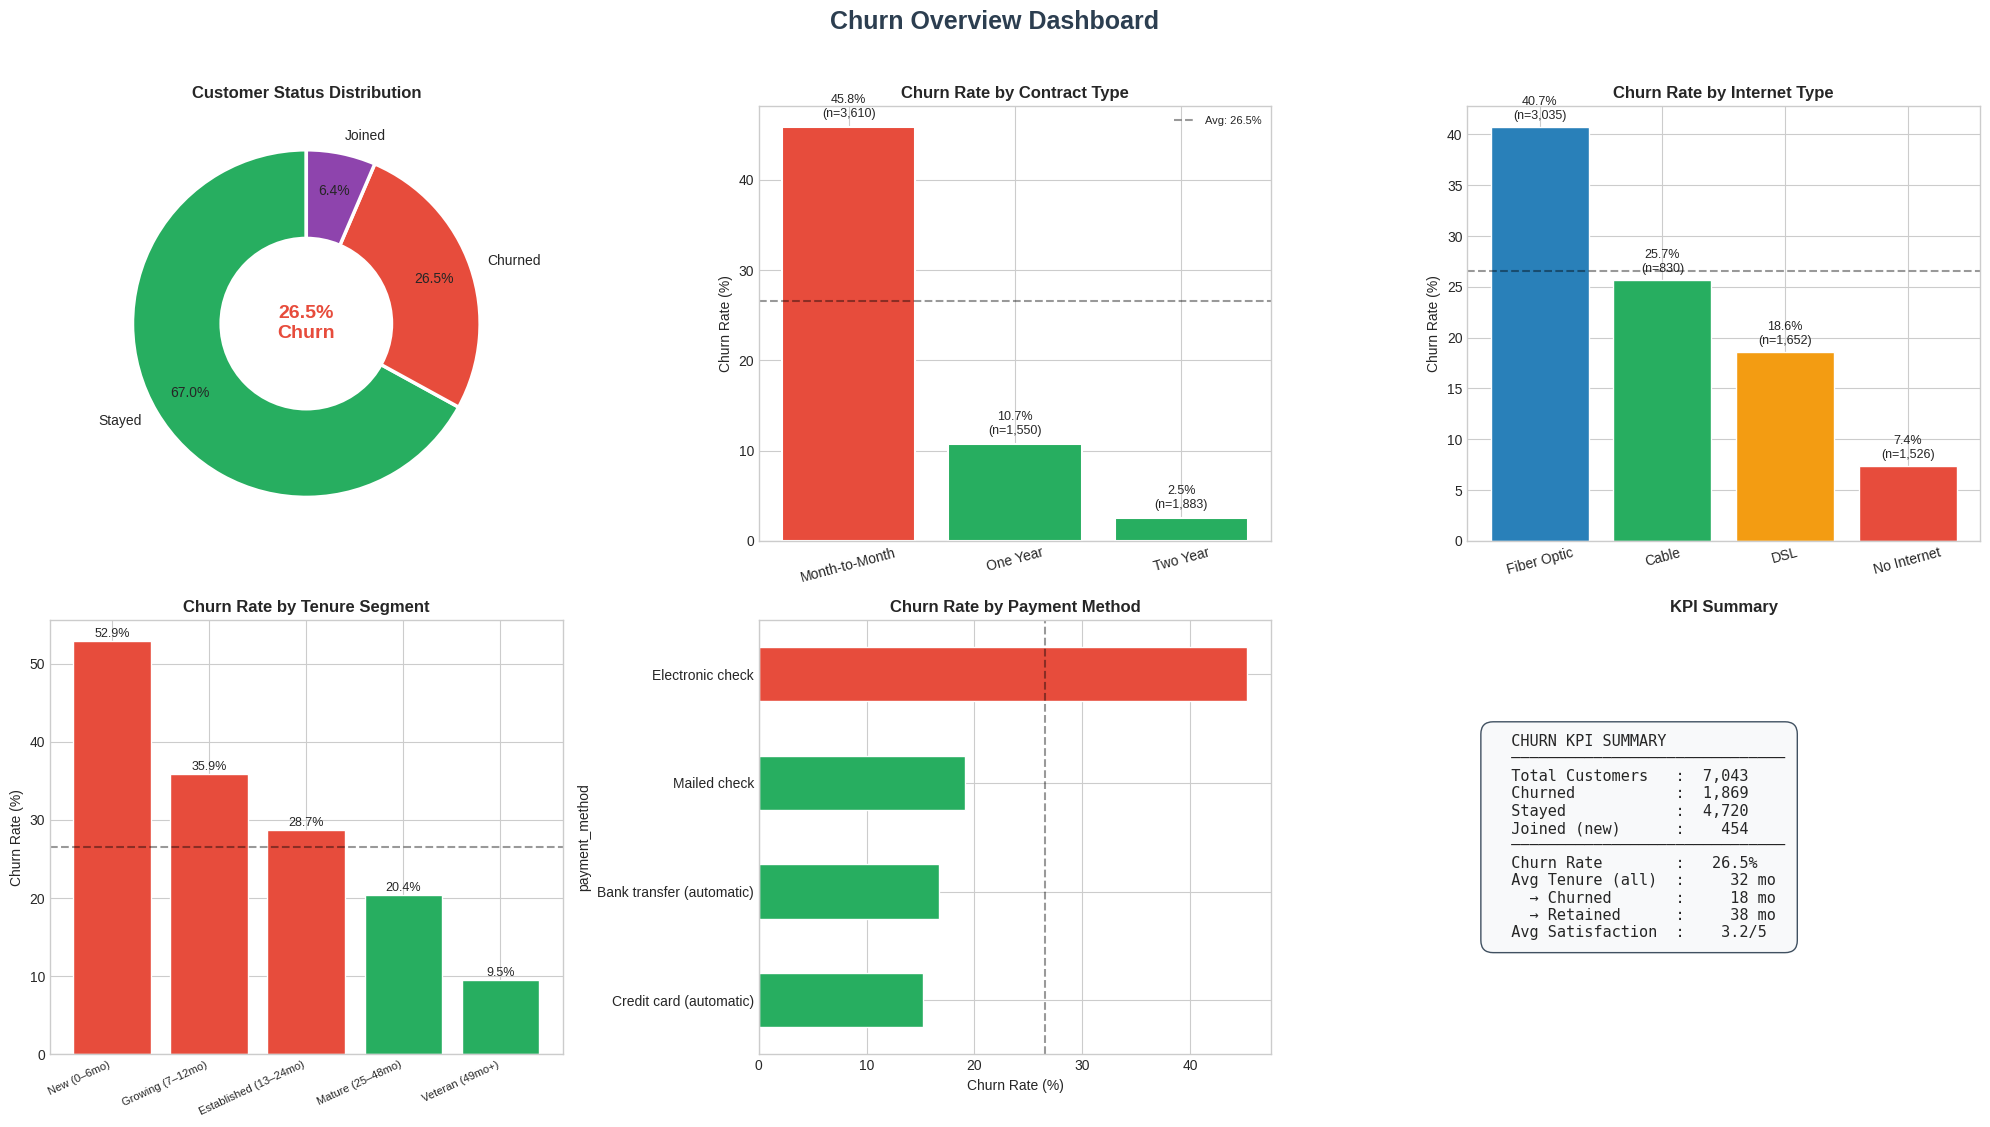

In [ ]:
os.makedirs('outputs', exist_ok=True)

# ═══════════════════════════════════════════════════════════════
# EDA 4.1: CHURN OVERVIEW DASHBOARD
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Churn Overview Dashboard', fontsize=18, fontweight='bold',
             color=COLORS['dark'], y=1.02)

overall_churn = df_master['is_churned'].mean()

# ── 1a. Donut chart: Overall churn rate ──
churn_counts = df_master['customer_status'].value_counts()
colors_3 = [COLORS['retain'], COLORS['churn'], COLORS['joined']]
wedges, texts, autotexts = axes[0,0].pie(
    churn_counts, labels=churn_counts.index,
    colors=colors_3, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    pctdistance=0.78, textprops={'fontsize': 10}
)
centre = plt.Circle((0,0), 0.50, fc='white')
axes[0,0].add_artist(centre)
axes[0,0].text(0, 0, f'{overall_churn*100:.1f}%\nChurn', ha='center', va='center',
               fontsize=14, fontweight='bold', color=COLORS['churn'])
axes[0,0].set_title('Customer Status Distribution', fontweight='bold')

# ── 1b. Churn by Contract ──
contract_churn = (df_master.groupby('contract')['is_churned']
                  .agg(['mean', 'count'])
                  .sort_values('mean', ascending=False))
contract_churn['pct'] = contract_churn['mean'] * 100
bars = axes[0,1].bar(contract_churn.index, contract_churn['pct'],
                     color=[COLORS['churn'] if v > overall_churn*100
                            else COLORS['retain'] for v in contract_churn['pct']],
                     edgecolor='white', linewidth=1.5)
for bar, val, n in zip(bars, contract_churn['pct'], contract_churn['count']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                   f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)
axes[0,1].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.4,
                   label=f'Avg: {overall_churn*100:.1f}%')
axes[0,1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].legend(fontsize=8)
axes[0,1].tick_params(axis='x', rotation=15)

# ── 1c. Churn by Internet Type ──
inet_churn = (df_master.groupby('internet_type')['is_churned']
              .agg(['mean', 'count']).sort_values('mean', ascending=False))
inet_churn['pct'] = inet_churn['mean'] * 100
bars = axes[0,2].bar(inet_churn.index, inet_churn['pct'],
                     color=PAL[:len(inet_churn)], edgecolor='white')
for bar, val, n in zip(bars, inet_churn['pct'], inet_churn['count']):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)
axes[0,2].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.4)
axes[0,2].set_title('Churn Rate by Internet Type', fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].tick_params(axis='x', rotation=15)

# ── 1d. Churn by Tenure Segment ──
seg_churn = df_master.groupby('tenure_segment')['is_churned'].mean() * 100
bars = axes[1,0].bar(range(len(seg_churn)), seg_churn.values,
                     color=[COLORS['churn'] if v > overall_churn*100 else COLORS['retain']
                            for v in seg_churn.values], edgecolor='white')
axes[1,0].set_xticks(range(len(seg_churn)))
axes[1,0].set_xticklabels(seg_churn.index, rotation=25, ha='right', fontsize=8)
axes[1,0].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.4)
axes[1,0].set_title('Churn Rate by Tenure Segment', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, seg_churn.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', fontsize=9)

# ── 1e. Churn by Payment Method ──
pay_churn = (df_master.groupby('payment_method')['is_churned']
             .mean().mul(100).sort_values(ascending=True))
colors_pay = [COLORS['churn'] if v > overall_churn*100 else COLORS['retain']
              for v in pay_churn.values]
pay_churn.plot(kind='barh', ax=axes[1,1], color=colors_pay, edgecolor='white')
axes[1,1].axvline(x=overall_churn*100, color='black', linestyle='--', alpha=0.4)
axes[1,1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1,1].set_xlabel('Churn Rate (%)')

# ── 1f. KPI Summary Card ──
churned_df = df_master[df_master['is_churned']==1]
retained_df = df_master[df_master['is_churned']==0]
kpi_text = (
    f"  CHURN KPI SUMMARY\n"
    f"  {'─'*30}\n"
    f"  Total Customers   : {len(df_master):>6,}\n"
    f"  Churned           : {churned_df.shape[0]:>6,}\n"
    f"  Stayed            : {(df_master['customer_status']=='Stayed').sum():>6,}\n"
    f"  Joined (new)      : {(df_master['customer_status']=='Joined').sum():>6,}\n"
    f"  {'─'*30}\n"
    f"  Churn Rate        : {overall_churn*100:>6.1f}%\n"
    f"  Avg Tenure (all)  : {df_master['tenure'].mean():>6.0f} mo\n"
    f"    → Churned       : {churned_df['tenure'].mean():>6.0f} mo\n"
    f"    → Retained      : {retained_df['tenure'].mean():>6.0f} mo\n"
    f"  Avg Satisfaction  : {df_master['satisfaction_score'].mean():>6.1f}/5"
)
axes[1,2].text(0.05, 0.5, kpi_text, transform=axes[1,2].transAxes,
               fontsize=11, va='center', fontfamily='monospace',
               bbox=dict(boxstyle='round,pad=0.8', facecolor=COLORS['light_bg'],
                        edgecolor=COLORS['dark'], alpha=0.9))
axes[1,2].axis('off')
axes[1,2].set_title('KPI Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 Tenure Deep Dive — Hypothesis H3

> **FINDING:** Churn terkonsentrasi di pelanggan dengan tenure ≤12 bulan: **47.4%** churn rate
> vs **17.1%** untuk tenure >12 bulan (rasio 2.8×). Chi-square test mengkonfirmasi signifikansi
> statistik (χ² = 708.78, p = 3.68e-156). Survival curve menunjukkan drop paling tajam
> di bulan-bulan awal, terutama bulan 1–6.
>
> **Business Implication:** ROI tertinggi ada di **onboarding & early engagement program** —
> hampir separuh pelanggan di tahun pertama akan churn jika tidak diintervensi.
> Investasi pada winback campaign untuk pelanggan lama kurang efisien dibanding pencegahan dini.
>
> **H3 ✓ CONFIRMED** — Early tenure (≤12mo) churn rate 47.4% vs overall 26.5%

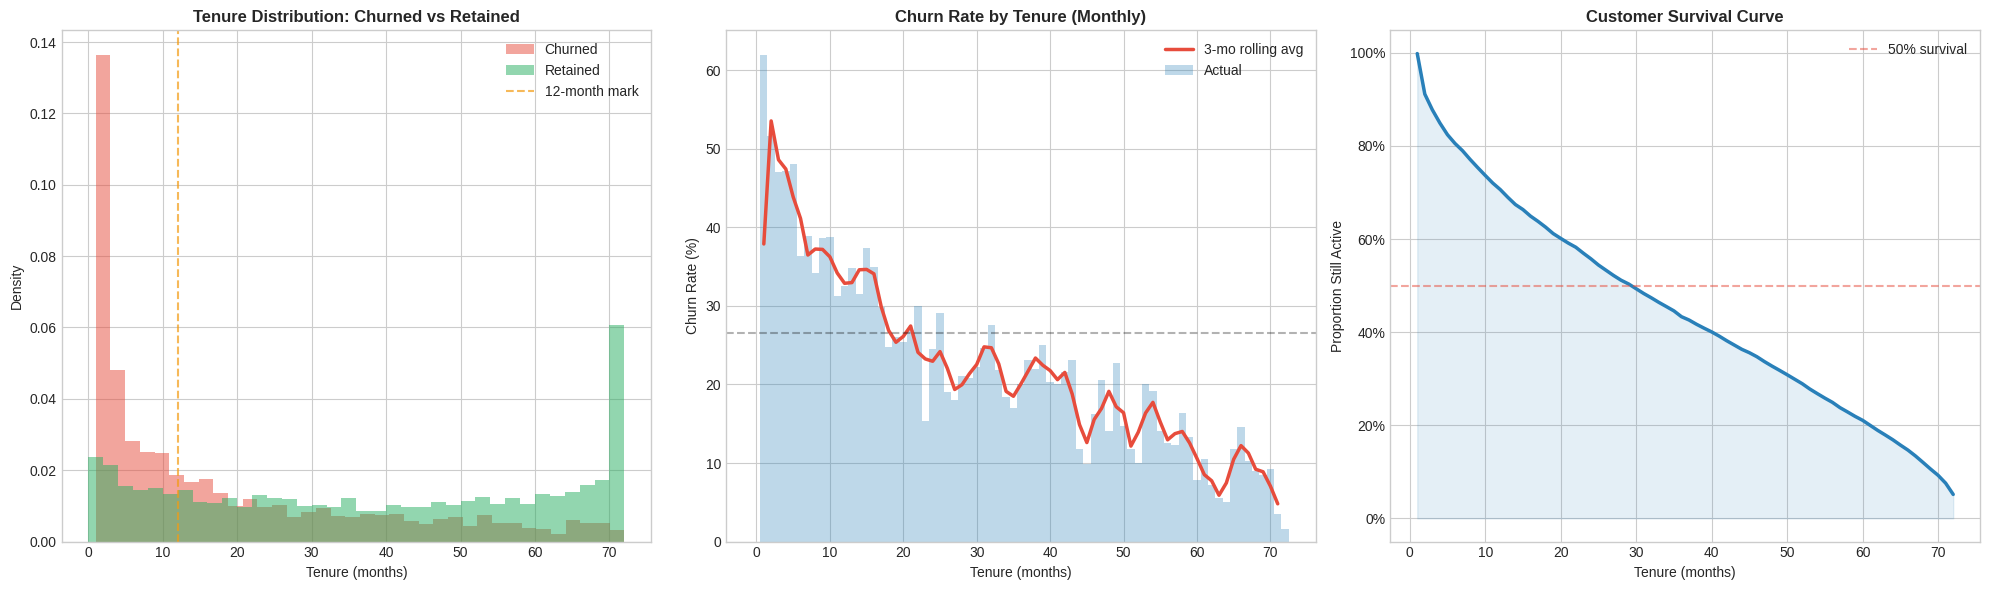


═══════════════════════════════════════════════════════
  H3 TEST: Churn Concentrated in Tenure ≤ 12 months
═══════════════════════════════════════════════════════
  Overall churn rate      : 26.5%
  Early tenure (≤12mo)    : 47.4%
  Later tenure (>12mo)    : 17.1%
  Ratio (early / later)   : 2.8×
  Chi-square              : 708.78
  p-value                 : 3.68e-156

  H3 ✓ CONFIRMED: Early tenure churn = 47.4% vs avg 26.5%


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EDA 4.2: TENURE ANALYSIS — Hypothesis H3
# ═══════════════════════════════════════════════════════════════
# Business question: Kapan dalam lifecycle churn paling terjadi?

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 2a. Tenure distribution: Churned vs Retained ──
for label, color, name in [(1, COLORS['churn'], 'Churned'),
                            (0, COLORS['retain'], 'Retained')]:
    subset = df_master[df_master['is_churned']==label]['tenure']
    axes[0].hist(subset, bins=36, alpha=0.5, color=color, label=name, density=True)
axes[0].axvline(x=12, color=COLORS['warning'], linestyle='--', alpha=0.7, label='12-month mark')
axes[0].set_title('Tenure Distribution: Churned vs Retained', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── 2b. Churn rate by tenure bucket (with rolling average) ──
tenure_churn = df_master.groupby('tenure')['is_churned'].agg(['mean', 'count'])
tenure_churn['rolling'] = tenure_churn['mean'].rolling(3, center=True).mean()
axes[1].bar(tenure_churn.index, tenure_churn['mean']*100,
            alpha=0.3, color=COLORS['neutral'], width=1.0, label='Actual')
axes[1].plot(tenure_churn.index, tenure_churn['rolling']*100,
             color=COLORS['churn'], linewidth=2.5, label='3-mo rolling avg')
axes[1].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.3)
axes[1].set_title('Churn Rate by Tenure (Monthly)', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

# ── 2c. Simplified Survival Curve ──
tenure_max = int(df_master['tenure'].max())
survival = [(df_master['tenure'] >= t).mean() for t in range(1, tenure_max+1)]
axes[2].plot(range(1, tenure_max+1), survival, color=COLORS['neutral'], linewidth=2.5)
axes[2].fill_between(range(1, tenure_max+1), survival, alpha=0.12, color=COLORS['neutral'])
axes[2].axhline(y=0.5, color=COLORS['churn'], linestyle='--', alpha=0.5, label='50% survival')
axes[2].set_title('Customer Survival Curve', fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Proportion Still Active')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/02_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── H3 HYPOTHESIS TEST ──
early_churn = df_master[df_master['tenure'] <= 12]['is_churned'].mean()
late_churn = df_master[df_master['tenure'] > 12]['is_churned'].mean()

contingency = pd.crosstab(df_master['tenure'] <= 12, df_master['is_churned'])
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"\n{'═'*55}")
print(f"  H3 TEST: Churn Concentrated in Tenure ≤ 12 months")
print(f"{'═'*55}")
print(f"  Overall churn rate      : {overall_churn*100:.1f}%")
print(f"  Early tenure (≤12mo)    : {early_churn*100:.1f}%")
print(f"  Later tenure (>12mo)    : {late_churn*100:.1f}%")
print(f"  Ratio (early / later)   : {early_churn / max(late_churn, 0.001):.1f}×")
print(f"  Chi-square              : {chi2:.2f}")
print(f"  p-value                 : {p_val:.2e}")
confirmed_h3 = early_churn > overall_churn and p_val < 0.05
print(f"\n  H3 {'✓ CONFIRMED' if confirmed_h3 else '✗ NOT CONFIRMED'}: "
      f"Early tenure churn = {early_churn*100:.1f}% vs avg {overall_churn*100:.1f}%")

## 4.3 Revenue Impact Analysis

> **FINDING:** Total revenue lost akibat churn: **\$3,684,460** (17.2% dari total \$21,371,132).
> Pelanggan yang churn membayar monthly charges rata-rata **\$74.44** — justru **lebih tinggi** > dari pelanggan retained (\$61.27). Perbedaan ini signifikan secara statistik
> (Mann-Whitney U, p = 3.31e-54).
>
> **Business Implication:** Churn bukan hanya masalah headcount — ini adalah **revenue leakage
> yang terkonsentrasi pada pelanggan high-value**. Paradoks: pelanggan yang membayar lebih mahal
> justru lebih rentan churn. Ini mengindikasikan perceived value gap — mereka merasa
> tidak mendapat value yang sebanding dengan harga yang dibayar.
>
> **Revenue at risk terbesar** ada di segmen New (0–6 bulan) dan High-End charges tier.

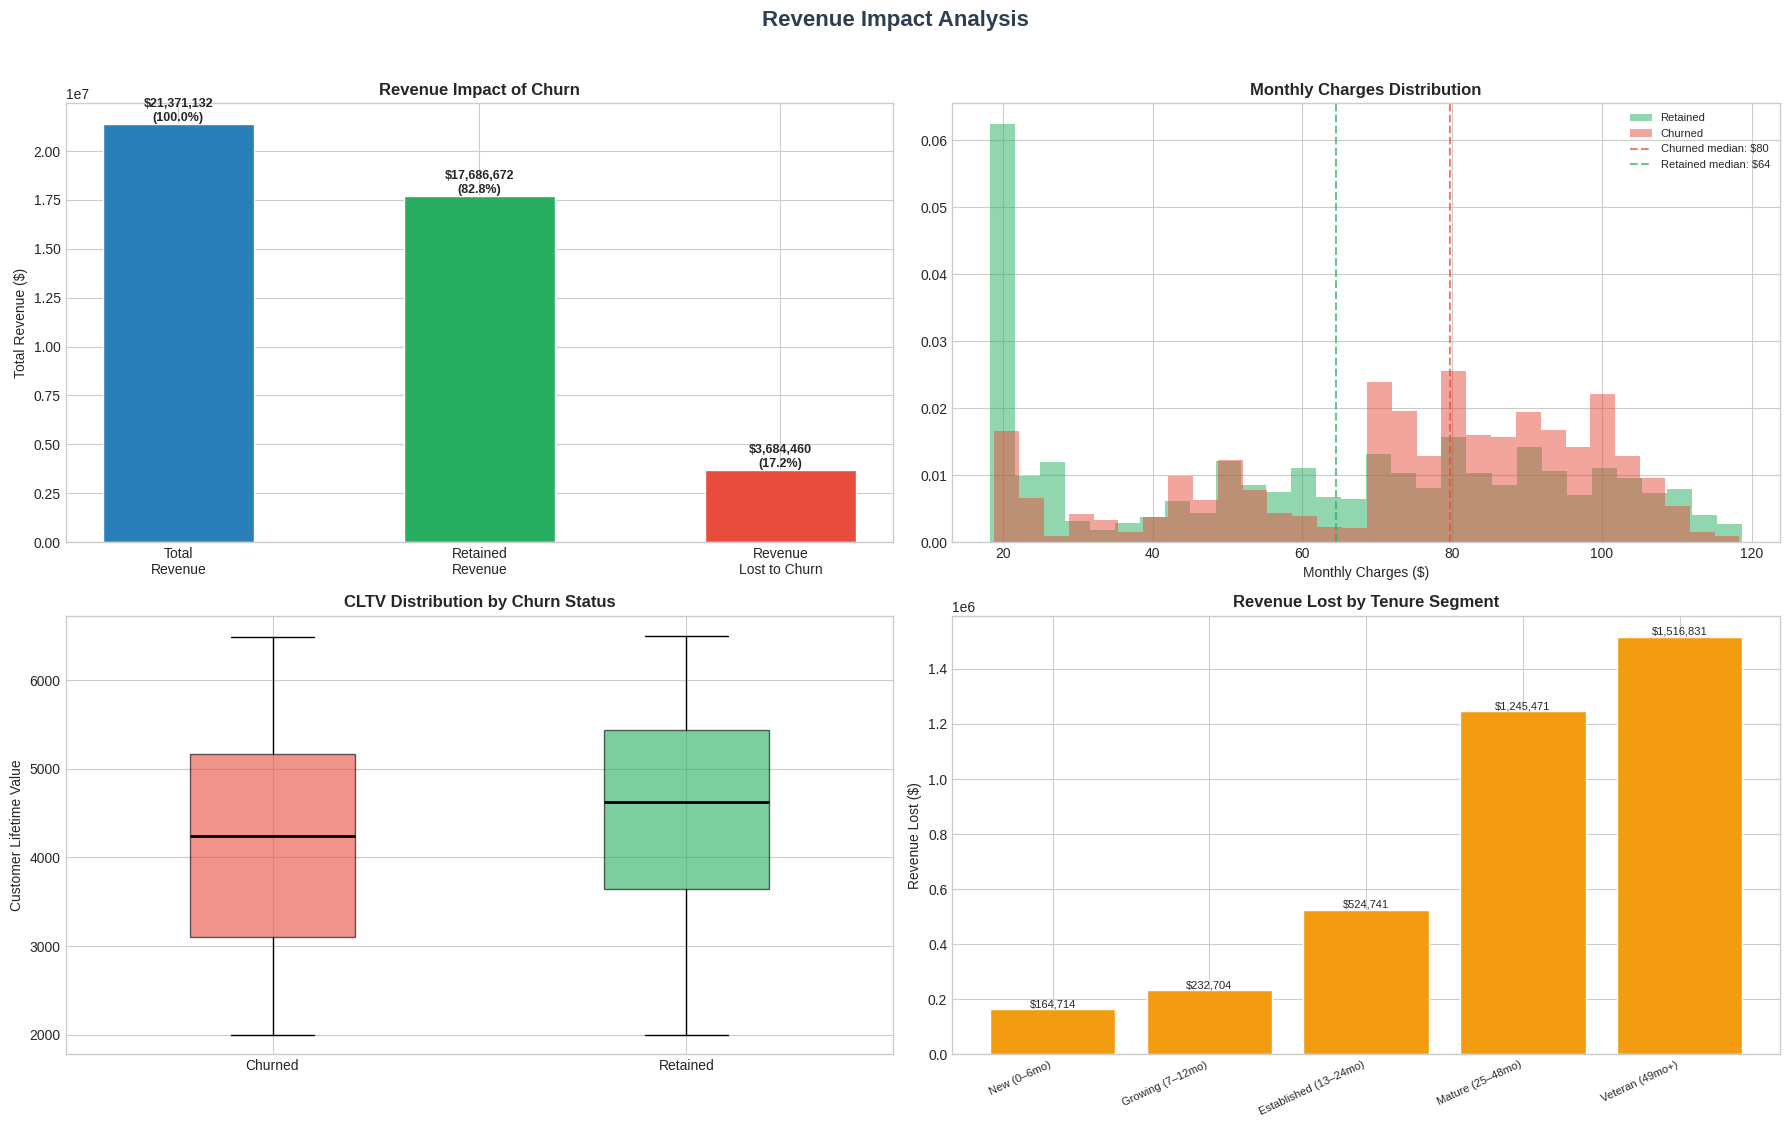


═══════════════════════════════════════════════════════
  REVENUE IMPACT SUMMARY
═══════════════════════════════════════════════════════
  Total revenue            : $  21,371,132
  Revenue retained         : $  17,686,672 (82.8%)
  Revenue lost to churn    : $   3,684,460 (17.2%)
  Avg monthly (churned)    : $   74.44
  Avg monthly (retained)   : $   61.27
  Mann-Whitney U p-value   : 3.31e-54 (Significant)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EDA 4.3: REVENUE IMPACT
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# ── 3a. Revenue: Total vs Retained vs Lost ──
rev_churned = churned_df['total_revenue'].sum()
rev_retained = retained_df['total_revenue'].sum()
rev_total = df_master['total_revenue'].sum()

bars = axes[0,0].bar(['Total\nRevenue', 'Retained\nRevenue', 'Revenue\nLost to Churn'],
                     [rev_total, rev_retained, rev_churned],
                     color=[COLORS['neutral'], COLORS['retain'], COLORS['churn']],
                     edgecolor='white', width=0.5)
for bar, val in zip(bars, [rev_total, rev_retained, rev_churned]):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                   f'${val:,.0f}\n({val/rev_total*100:.1f}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,0].set_title('Revenue Impact of Churn', fontweight='bold')
axes[0,0].set_ylabel('Total Revenue ($)')

# ── 3b. Monthly Charges: Churned vs Retained ──
axes[0,1].hist(retained_df['monthly_charges'], bins=30, alpha=0.5,
               color=COLORS['retain'], label='Retained', density=True)
axes[0,1].hist(churned_df['monthly_charges'], bins=30, alpha=0.5,
               color=COLORS['churn'], label='Churned', density=True)
axes[0,1].axvline(x=churned_df['monthly_charges'].median(), color=COLORS['churn'],
                  linestyle='--', alpha=0.7, label=f"Churned median: ${churned_df['monthly_charges'].median():.0f}")
axes[0,1].axvline(x=retained_df['monthly_charges'].median(), color=COLORS['retain'],
                  linestyle='--', alpha=0.7, label=f"Retained median: ${retained_df['monthly_charges'].median():.0f}")
axes[0,1].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0,1].set_xlabel('Monthly Charges ($)')
axes[0,1].legend(fontsize=8)

# ── 3c. CLTV by churn status ──
bp = axes[1,0].boxplot(
    [churned_df['cltv'].dropna(), retained_df['cltv'].dropna()],
    labels=['Churned', 'Retained'], patch_artist=True, widths=0.4,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set(facecolor=COLORS['churn'], alpha=0.6)
bp['boxes'][1].set(facecolor=COLORS['retain'], alpha=0.6)
axes[1,0].set_title('CLTV Distribution by Churn Status', fontweight='bold')
axes[1,0].set_ylabel('Customer Lifetime Value')

# ── 3d. Revenue at Risk by Tenure Segment ──
rev_risk = churned_df.groupby('tenure_segment')['total_revenue'].sum()
rev_risk = rev_risk.reindex(df_master['tenure_segment'].cat.categories, fill_value=0)
bars = axes[1,1].bar(range(len(rev_risk)), rev_risk.values,
                     color=COLORS['warning'], edgecolor='white')
axes[1,1].set_xticks(range(len(rev_risk)))
axes[1,1].set_xticklabels(rev_risk.index, rotation=25, ha='right', fontsize=8)
axes[1,1].set_title('Revenue Lost by Tenure Segment', fontweight='bold')
axes[1,1].set_ylabel('Revenue Lost ($)')
for bar, val in zip(bars, rev_risk.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                   f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Revenue Impact Analysis', fontsize=16, fontweight='bold',
             color=COLORS['dark'], y=1.02)
plt.tight_layout()
plt.savefig('outputs/03_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Revenue summary
print(f"\n{'═'*55}")
print("  REVENUE IMPACT SUMMARY")
print(f"{'═'*55}")
print(f"  Total revenue            : ${rev_total:>12,.0f}")
print(f"  Revenue retained         : ${rev_retained:>12,.0f} ({rev_retained/rev_total*100:.1f}%)")
print(f"  Revenue lost to churn    : ${rev_churned:>12,.0f} ({rev_churned/rev_total*100:.1f}%)")
print(f"  Avg monthly (churned)    : ${churned_df['monthly_charges'].mean():>8,.2f}")
print(f"  Avg monthly (retained)   : ${retained_df['monthly_charges'].mean():>8,.2f}")

u_stat, p_mw = mannwhitneyu(churned_df['monthly_charges'], retained_df['monthly_charges'])
print(f"  Mann-Whitney U p-value   : {p_mw:.2e} ({'Significant' if p_mw < 0.05 else 'Not significant'})")

## 4.4 Service Adoption Analysis — Hypotheses H2 & H4

> **FINDING:** Pelanggan **tanpa Premium Tech Support** memiliki churn rate **31.2%** vs **15.2%**
> dengan TechSupport (Δ = 16.0pp, χ² = 190.2, p = 2.92e-43). Tanpa **Online Security**:
> churn **31.3%** vs **14.6%** (Δ = 16.7pp, χ² = 205.6, p = 1.23e-46).
>
> **Fiber Optic paradox:** churn rate tertinggi di **40.7%** (n=3,035) — jauh di atas DSL (18.6%)
> dan Cable (25.7%), padahal Fiber Optic memiliki monthly charges tertinggi.
> Pelanggan tanpa internet hanya 7.4% churn.
>
> Setiap tambahan service yang di-subscribe cenderung menurunkan churn rate — service adoption
> berfungsi sebagai retention "moat" yang membuat pelanggan lebih sticky.
>
> **H2 ✓ CONFIRMED** — TechSupport & OnlineSecurity secara signifikan mengurangi churn
> **H4 ✓ CONFIRMED** — Fiber Optic (40.7%) > DSL (18.6%) > Cable (25.7%)

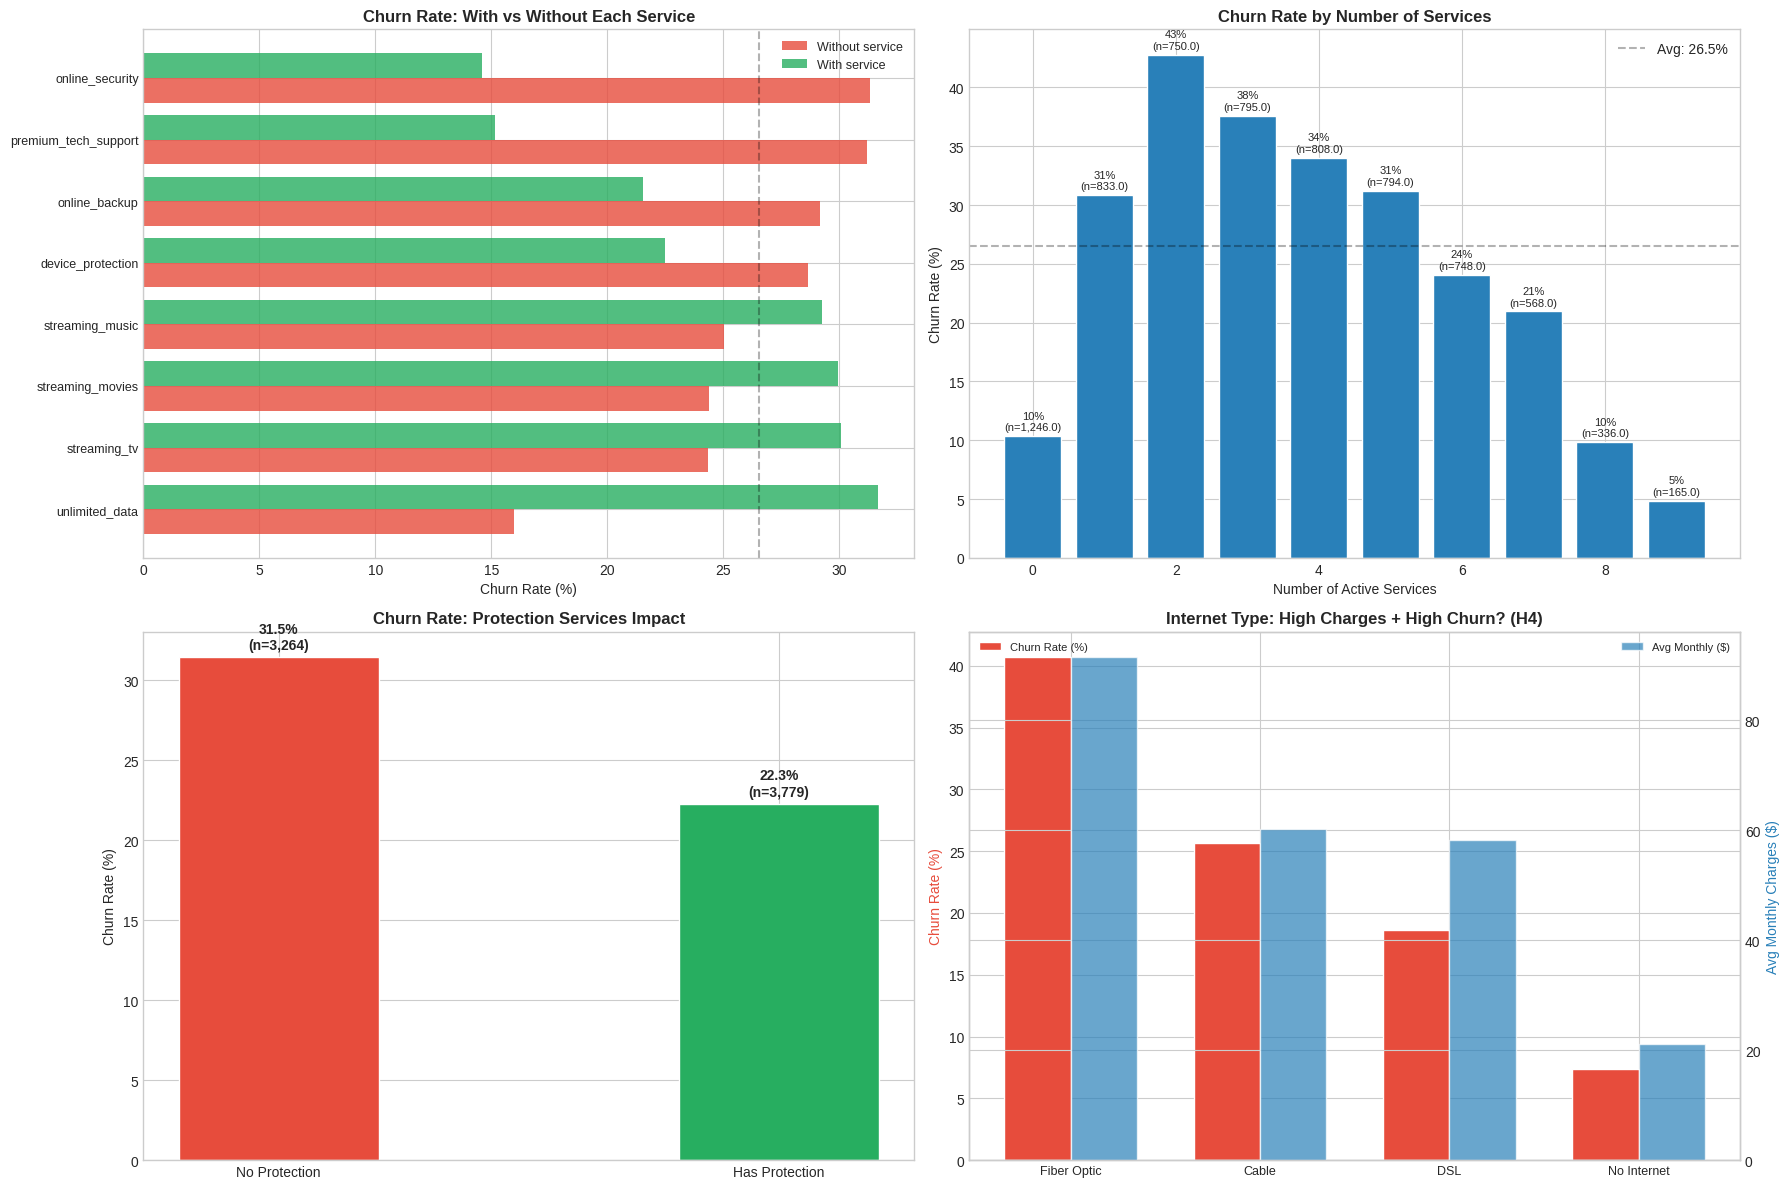


═══════════════════════════════════════════════════════
  H2 TEST: TechSupport & OnlineSecurity Reduce Churn
═══════════════════════════════════════════════════════
  premium_tech_support:
    Yes → 15.2%  |  No → 31.2%  |  Δ = 16.0pp
    Chi-sq = 190.2, p = 2.92e-43
  online_security:
    Yes → 14.6%  |  No → 31.3%  |  Δ = 16.7pp
    Chi-sq = 205.6, p = 1.23e-46

  H2 ✓ CONFIRMED

═══════════════════════════════════════════════════════
  H4 TEST: Fiber Optic Churn > DSL/Cable
═══════════════════════════════════════════════════════
  Cable           → churn: 25.7%  (n=830)
  Fiber Optic     → churn: 40.7%  (n=3,035)
  DSL             → churn: 18.6%  (n=1,652)
  No Internet     → churn: 7.4%  (n=1,526)

  H4 ✓ CONFIRMED: Fiber Optic (40.7%) > DSL (18.6%)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EDA 4.4: SERVICE ADOPTION vs CHURN — H2 & H4
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── 4a. Churn rate per service (Yes vs No) — horizontal bar ──
service_cols_yn = ['online_security', 'online_backup', 'device_protection',
                   'premium_tech_support', 'streaming_tv', 'streaming_movies',
                   'streaming_music', 'unlimited_data']
service_impact = {}
for col in service_cols_yn:
    if col in df_master.columns:
        yes_rate = df_master[df_master[col]=='Yes']['is_churned'].mean() * 100
        no_rate = df_master[df_master[col]=='No']['is_churned'].mean() * 100
        service_impact[col] = {'Yes': yes_rate, 'No': no_rate, 'diff': no_rate - yes_rate}

si_df = pd.DataFrame(service_impact).T.sort_values('diff', ascending=True)
y_pos = range(len(si_df))
axes[0,0].barh(y_pos, si_df['No'], height=0.4, color=COLORS['churn'],
               label='Without service', alpha=0.8)
axes[0,0].barh([y+0.4 for y in y_pos], si_df['Yes'], height=0.4,
               color=COLORS['retain'], label='With service', alpha=0.8)
axes[0,0].set_yticks([y+0.2 for y in y_pos])
axes[0,0].set_yticklabels(si_df.index, fontsize=9)
axes[0,0].axvline(x=overall_churn*100, color='black', linestyle='--', alpha=0.3)
axes[0,0].set_title('Churn Rate: With vs Without Each Service', fontweight='bold')
axes[0,0].set_xlabel('Churn Rate (%)')
axes[0,0].legend(fontsize=9)

# ── 4b. Service count vs churn rate ──
svc_count_churn = df_master.groupby('n_services')['is_churned'].agg(['mean', 'count'])
bars = axes[0,1].bar(svc_count_churn.index, svc_count_churn['mean']*100,
                     color=COLORS['neutral'], edgecolor='white')
axes[0,1].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.3,
                   label=f'Avg: {overall_churn*100:.1f}%')
axes[0,1].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[0,1].set_xlabel('Number of Active Services')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].legend()
for bar, (idx, row) in zip(bars, svc_count_churn.iterrows()):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{row["mean"]*100:.0f}%\n(n={row["count"]:,})',
                   ha='center', fontsize=8)

# ── 4c. Protection bundle impact ──
prot_churn = df_master.groupby('has_protection')['is_churned'].mean() * 100
prot_n = df_master.groupby('has_protection')['is_churned'].count()
labels_p = ['No Protection', 'Has Protection']
bars = axes[1,0].bar(labels_p, prot_churn.values,
                     color=[COLORS['churn'], COLORS['retain']], edgecolor='white', width=0.4)
axes[1,0].set_title('Churn Rate: Protection Services Impact', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for bar, val, n in zip(bars, prot_churn.values, prot_n.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%\n(n={n:,})', ha='center', fontweight='bold', fontsize=10)

# ── 4d. Internet type: churn rate + avg charges (dual axis) ──
inet_data = df_master.groupby('internet_type').agg(
    churn_rate=('is_churned', 'mean'),
    avg_charges=('monthly_charges', 'mean'),
    n=('is_churned', 'count')
).sort_values('churn_rate', ascending=False)
inet_data['churn_pct'] = inet_data['churn_rate'] * 100

x = range(len(inet_data))
w = 0.35
bars1 = axes[1,1].bar([i-w/2 for i in x], inet_data['churn_pct'], width=w,
                       color=COLORS['churn'], label='Churn Rate (%)', edgecolor='white')
ax2 = axes[1,1].twinx()
bars2 = ax2.bar([i+w/2 for i in x], inet_data['avg_charges'], width=w,
                color=COLORS['neutral'], label='Avg Monthly ($)', edgecolor='white', alpha=0.7)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(inet_data.index, fontsize=9)
axes[1,1].set_ylabel('Churn Rate (%)', color=COLORS['churn'])
ax2.set_ylabel('Avg Monthly Charges ($)', color=COLORS['neutral'])
axes[1,1].set_title('Internet Type: High Charges + High Churn? (H4)', fontweight='bold')
axes[1,1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/04_service_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── H2 & H4 Tests ──
print(f"\n{'═'*55}")
print("  H2 TEST: TechSupport & OnlineSecurity Reduce Churn")
print(f"{'═'*55}")
for col in ['premium_tech_support', 'online_security']:
    yes_r = df_master[df_master[col]=='Yes']['is_churned'].mean()
    no_r = df_master[df_master[col]=='No']['is_churned'].mean()
    ct = pd.crosstab(df_master[col], df_master['is_churned'])
    chi2_s, p_s, _, _ = chi2_contingency(ct)
    print(f"  {col}:")
    print(f"    Yes → {yes_r*100:.1f}%  |  No → {no_r*100:.1f}%  |  Δ = {(no_r-yes_r)*100:.1f}pp")
    print(f"    Chi-sq = {chi2_s:.1f}, p = {p_s:.2e}")

confirmed_h2 = no_r > yes_r and p_s < 0.05
print(f"\n  H2 {'✓ CONFIRMED' if confirmed_h2 else '✗ NOT CONFIRMED'}")

print(f"\n{'═'*55}")
print("  H4 TEST: Fiber Optic Churn > DSL/Cable")
print(f"{'═'*55}")
for itype in df_master['internet_type'].unique():
    r = df_master[df_master['internet_type']==itype]['is_churned'].mean()
    n = (df_master['internet_type']==itype).sum()
    print(f"  {itype:15} → churn: {r*100:.1f}%  (n={n:,})")
fiber_r = df_master[df_master['internet_type']=='Fiber Optic']['is_churned'].mean()
dsl_r = df_master[df_master['internet_type']=='DSL']['is_churned'].mean()
confirmed_h4 = fiber_r > dsl_r
print(f"\n  H4 {'✓ CONFIRMED' if confirmed_h4 else '✗ NOT CONFIRMED'}: "
      f"Fiber Optic ({fiber_r*100:.1f}%) > DSL ({dsl_r*100:.1f}%)")

## 4.5 Contract & Payment Behavior — Hypotheses H1 & H5

> **FINDING:** Month-to-Month pelanggan memiliki churn rate **45.8%** — dibanding **6.2%**
> untuk pelanggan kontrak tahunan (One Year + Two Year). Rasio **7.4×**, jauh melampaui
> threshold hipotesis 2× (χ² = 1414.2, p ≈ 0). Electronic check users memiliki churn **45.3%**
> vs auto-payment methods hanya **16.0%**.
>
> **Business Implication:** Contract commitment dan auto-payment setup adalah dua **"friction
> points" paling actionable** untuk mengurangi churn. Pelanggan tanpa kontrak secara harfiah
> 7× lebih mungkin churn. Migrasi ke kontrak tahunan dengan diskon insentif bisa menjadi
> quick win dengan impact terbesar.
>
> **H1 ✓ CONFIRMED** — MTM 45.8% ≥ 2× yearly 6.2% (ratio 7.4×)
> **H5 ✓ CONFIRMED** — Electronic check (45.3%) > Auto-pay (16.0%)

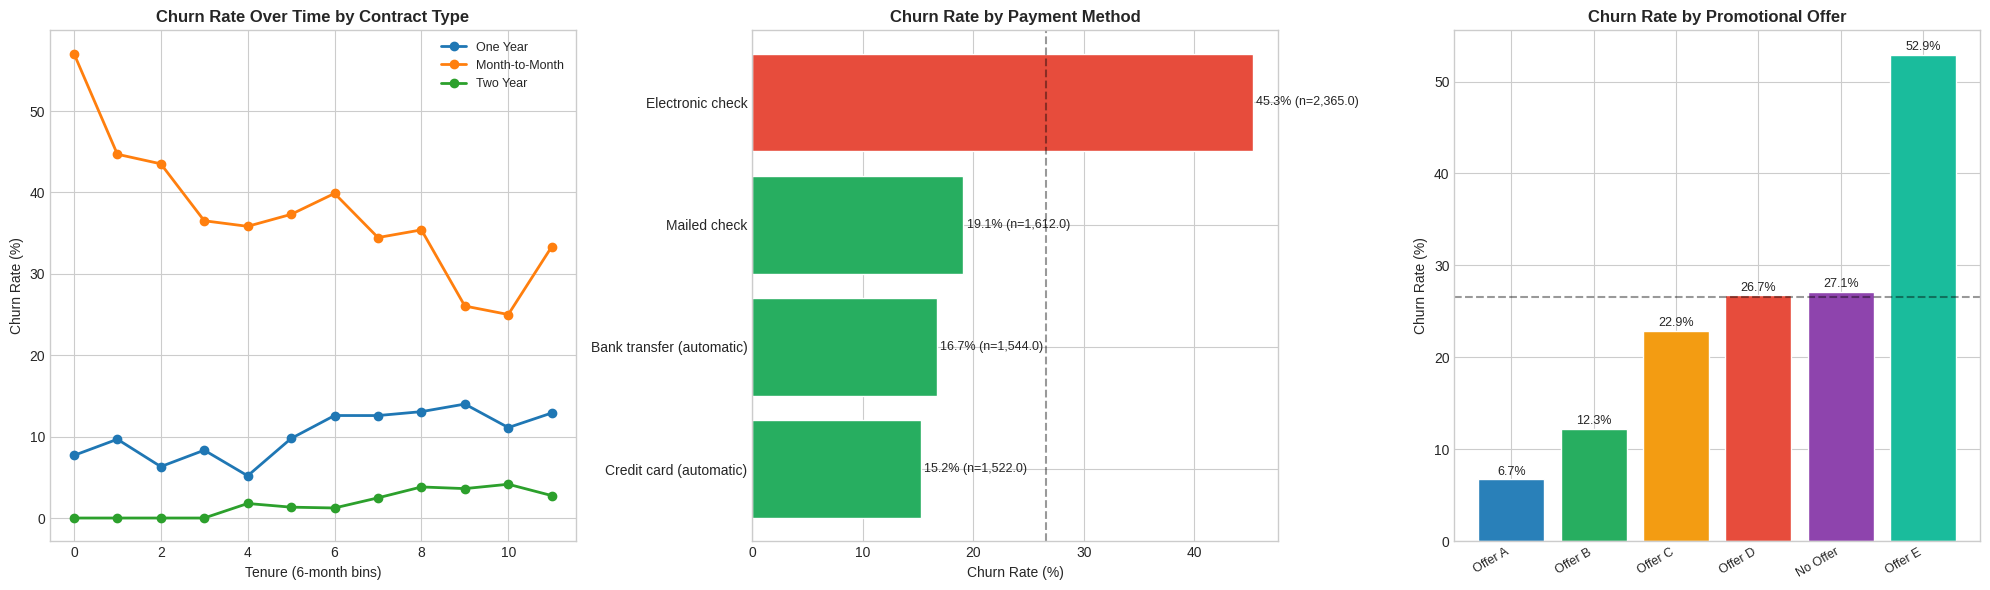


═══════════════════════════════════════════════════════
  H1 TEST: Month-to-Month ≥ 2× Yearly Churn
═══════════════════════════════════════════════════════
  Month-to-Month  : 45.8%
  Yearly (1yr+2yr): 6.2%
  Ratio           : 7.4×
  Chi-sq = 1414.2, p = 1.71e-309
  H1 ✓ CONFIRMED

═══════════════════════════════════════════════════════
  H5 TEST: Electronic Check > Auto-Payment Churn
═══════════════════════════════════════════════════════
  Electronic check : 45.3%
  Auto-pay methods : 16.0%
  H5 ✓ CONFIRMED


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EDA 4.5: CONTRACT & PAYMENT — H1 & H5
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 5a. Contract × Tenure interaction ──
for ctype in df_master['contract'].unique():
    sub = df_master[df_master['contract']==ctype]
    t_churn = sub.groupby(pd.cut(sub['tenure'], bins=range(0,78,6)))['is_churned'].mean()*100
    axes[0].plot(range(len(t_churn)), t_churn.values, marker='o', label=ctype, linewidth=2)
axes[0].set_title('Churn Rate Over Time by Contract Type', fontweight='bold')
axes[0].set_xlabel('Tenure (6-month bins)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend(fontsize=9)

# ── 5b. Payment method ──
pay_data = df_master.groupby('payment_method').agg(
    churn_rate=('is_churned', 'mean'), n=('is_churned', 'count')
).sort_values('churn_rate', ascending=True)
colors_p = [COLORS['churn'] if v > overall_churn else COLORS['retain']
            for v in pay_data['churn_rate']]
bars = axes[1].barh(pay_data.index, pay_data['churn_rate']*100,
                    color=colors_p, edgecolor='white')
axes[1].axvline(x=overall_churn*100, color='black', linestyle='--', alpha=0.4)
axes[1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for bar, (_, row) in zip(bars, pay_data.iterrows()):
    axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{row["churn_rate"]*100:.1f}% (n={row["n"]:,})',
                 va='center', fontsize=9)

# ── 5c. Offer type impact ──
offer_churn = df_master.groupby('offer')['is_churned'].agg(['mean','count']).sort_values('mean')
offer_churn['pct'] = offer_churn['mean'] * 100
bars = axes[2].bar(range(len(offer_churn)), offer_churn['pct'],
                   color=PAL[:len(offer_churn)], edgecolor='white')
axes[2].set_xticks(range(len(offer_churn)))
axes[2].set_xticklabels(offer_churn.index, rotation=30, ha='right', fontsize=9)
axes[2].axhline(y=overall_churn*100, color='black', linestyle='--', alpha=0.4)
axes[2].set_title('Churn Rate by Promotional Offer', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, offer_churn['pct']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/05_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()

# ── H1 & H5 Tests ──
mtm_churn = df_master[df_master['contract']=='Month-to-Month']['is_churned'].mean()
yearly = df_master[df_master['contract'].isin(['One Year','Two Year'])]['is_churned'].mean()
ct_h1 = pd.crosstab(df_master['contract']=='Month-to-Month', df_master['is_churned'])
chi2_h1, p_h1, _, _ = chi2_contingency(ct_h1)

print(f"\n{'═'*55}")
print(f"  H1 TEST: Month-to-Month ≥ 2× Yearly Churn")
print(f"{'═'*55}")
print(f"  Month-to-Month  : {mtm_churn*100:.1f}%")
print(f"  Yearly (1yr+2yr): {yearly*100:.1f}%")
print(f"  Ratio           : {mtm_churn/max(yearly,0.001):.1f}×")
print(f"  Chi-sq = {chi2_h1:.1f}, p = {p_h1:.2e}")
confirmed_h1 = mtm_churn >= 2 * yearly and p_h1 < 0.05
print(f"  H1 {'✓ CONFIRMED' if confirmed_h1 else '✗ NOT CONFIRMED'}")

echeck = df_master[df_master['payment_method']=='Electronic check']['is_churned'].mean()
auto = df_master[df_master['payment_method'].str.contains('automatic', case=False)]['is_churned'].mean()
print(f"\n{'═'*55}")
print(f"  H5 TEST: Electronic Check > Auto-Payment Churn")
print(f"{'═'*55}")
print(f"  Electronic check : {echeck*100:.1f}%")
print(f"  Auto-pay methods : {auto*100:.1f}%")
confirmed_h5 = echeck > auto
print(f"  H5 {'✓ CONFIRMED' if confirmed_h5 else '✗ NOT CONFIRMED'}")

## 4.6 Correlation Analysis & Variable Ranking

> **FINDING:** Top 5 variabel paling berkorelasi dengan churn:
> 1. **satisfaction_score** (r = −0.755) — semakin puas, semakin kecil churn
> 2. **churn_score** (r = +0.661) — existing risk metric yang valid
> 3. **tenure** (r = −0.352) — semakin lama berlangganan, semakin loyal
> 4. **number_of_referrals** (r = −0.287) — pelanggan yang mereferensikan = lebih engaged
> 5. **dependents_enc** (r = −0.249) — pelanggan dengan tanggungan cenderung bertahan
>
> Variabel yang meningkatkan churn: `internet_service_enc` (+0.228), menandakan pelanggan
> internet lebih rentan churn — terutama Fiber Optic.
>
> **Business Implication:** Satisfaction score adalah prediktor paling kuat — monitoring
> satisfaction menjadi early warning system paling efektif. Referral behavior juga menjadi
> signal positif: pelanggan yang aktif mereferensikan lebih kecil kemungkinan churn.

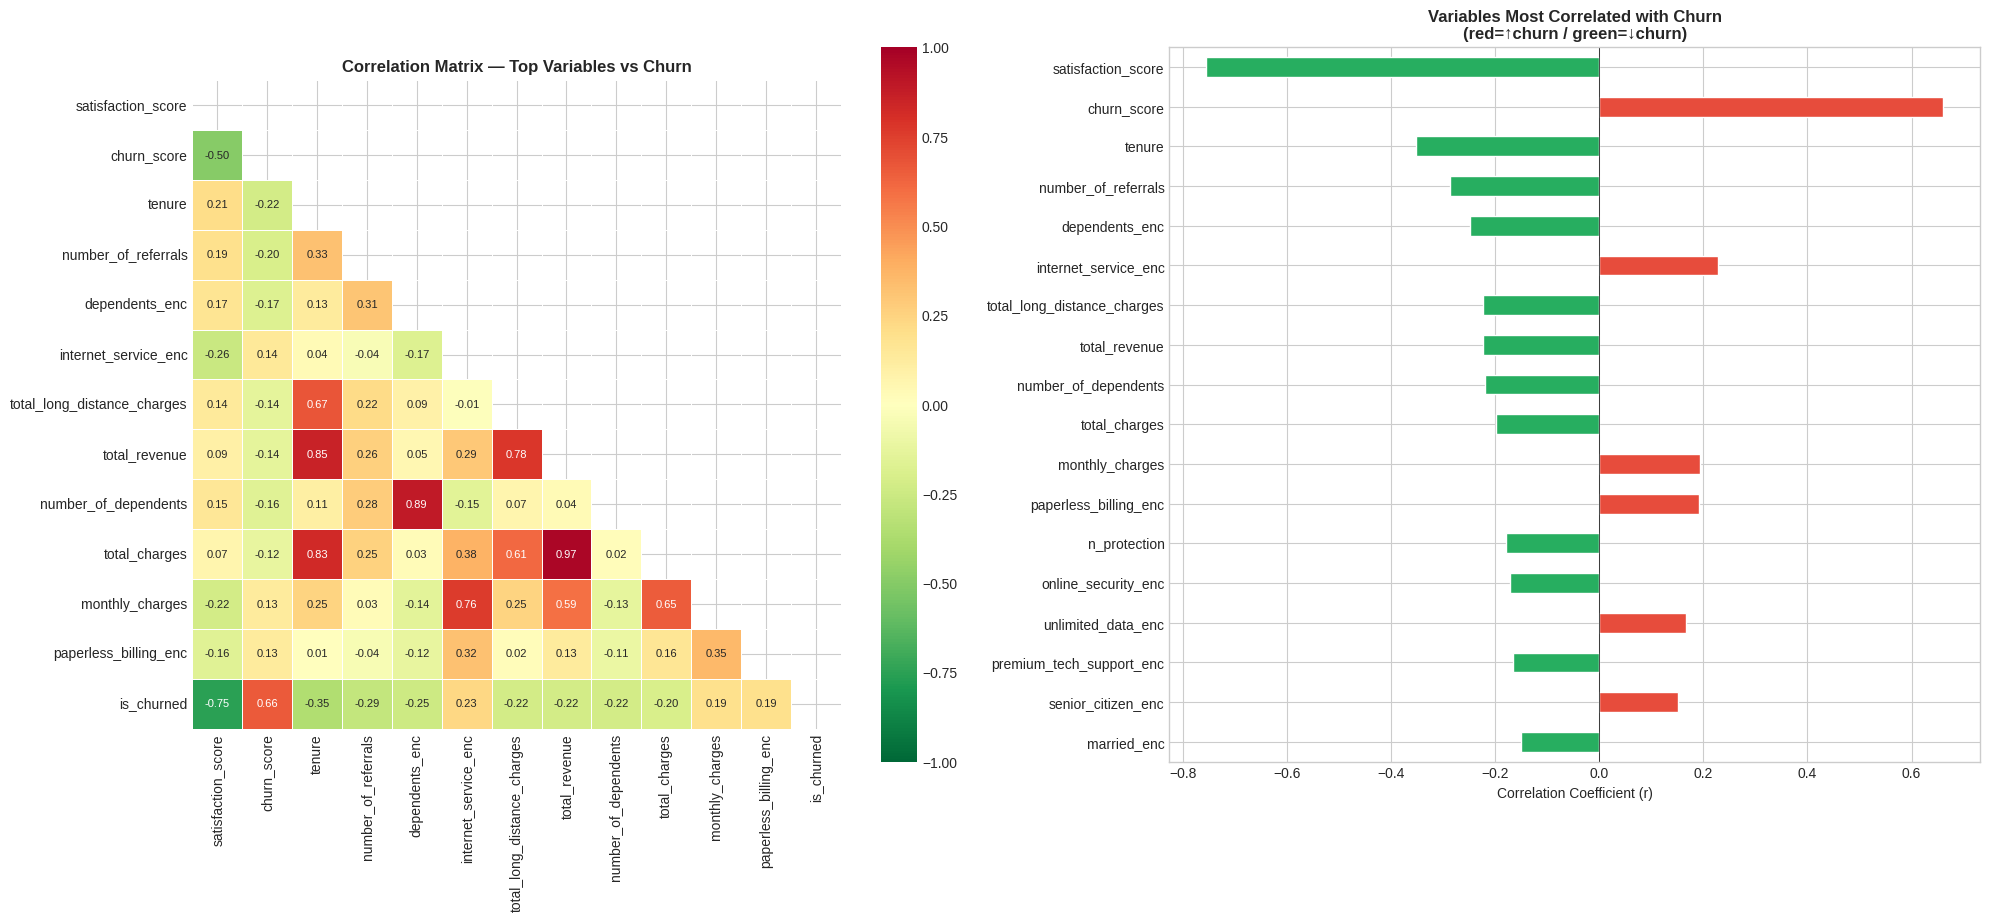


  TOP 10 CHURN CORRELATES:
  ──────────────────────────────────────────────────
   1. satisfaction_score                       r = -0.755  (↓ less churn)
   2. churn_score                              r = +0.661  (↑ more churn)
   3. tenure                                   r = -0.352  (↓ less churn)
   4. number_of_referrals                      r = -0.287  (↓ less churn)
   5. dependents_enc                           r = -0.249  (↓ less churn)
   6. internet_service_enc                     r = +0.228  (↑ more churn)
   7. total_long_distance_charges              r = -0.224  (↓ less churn)
   8. total_revenue                            r = -0.223  (↓ less churn)
   9. number_of_dependents                     r = -0.219  (↓ less churn)
  10. total_charges                            r = -0.199  (↓ less churn)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EDA 4.6: CORRELATION & VARIABLE IMPORTANCE
# ═══════════════════════════════════════════════════════════════

# Encode binary Yes/No columns untuk korelasi
df_corr = df_master.copy()
binary_cols = ['online_security', 'online_backup', 'device_protection',
               'premium_tech_support', 'streaming_tv', 'streaming_movies',
               'streaming_music', 'unlimited_data', 'multiple_lines',
               'phone_service', 'internet_service', 'paperless_billing',
               'partner', 'dependents', 'married', 'referred_a_friend',
               'senior_citizen', 'under_30']
for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col + '_enc'] = (df_corr[col].astype(str).str.strip().str.lower() == 'yes').astype(int)

# Select numeric columns
num_cols = ['tenure', 'monthly_charges', 'total_charges', 'total_revenue',
            'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges',
            'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
            'number_of_referrals', 'number_of_dependents', 'age',
            'satisfaction_score', 'cltv', 'churn_score', 'n_services',
            'n_protection', 'revenue_per_month', 'is_churned']
num_cols += [c for c in df_corr.columns if c.endswith('_enc')]
num_cols = [c for c in num_cols if c in df_corr.columns]

corr_with_churn = df_corr[num_cols].corr()['is_churned'].drop('is_churned')
corr_with_churn = corr_with_churn.dropna().sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ── 6a. Correlation heatmap (top variables) ──
top_vars = list(corr_with_churn.head(12).index) + ['is_churned']
corr_matrix = df_corr[top_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Correlation Matrix — Top Variables vs Churn', fontweight='bold')

# ── 6b. Variable importance ranking ──
top_n = min(18, len(corr_with_churn))
plot_data = corr_with_churn.head(top_n)[::-1]
colors_c = [COLORS['churn'] if v > 0 else COLORS['retain'] for v in plot_data.values]
plot_data.plot(kind='barh', ax=axes[1], color=colors_c, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_title('Variables Most Correlated with Churn\n(red=↑churn / green=↓churn)',
                  fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient (r)')

plt.tight_layout()
plt.savefig('outputs/06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  TOP 10 CHURN CORRELATES:")
print(f"  {'─'*50}")
for i, (var, r) in enumerate(corr_with_churn.head(10).items(), 1):
    arrow = "↑ more churn" if r > 0 else "↓ less churn"
    print(f"  {i:>2}. {var:40} r = {r:+.3f}  ({arrow})")

## 4.7 Churn Reason Analysis (Dataset Advantage)

> Dataset ini memiliki keunggulan: **explicit churn reasons** — data yang jarang tersedia
> di dataset publik. Ini memungkinkan root-cause analysis yang lebih dalam.

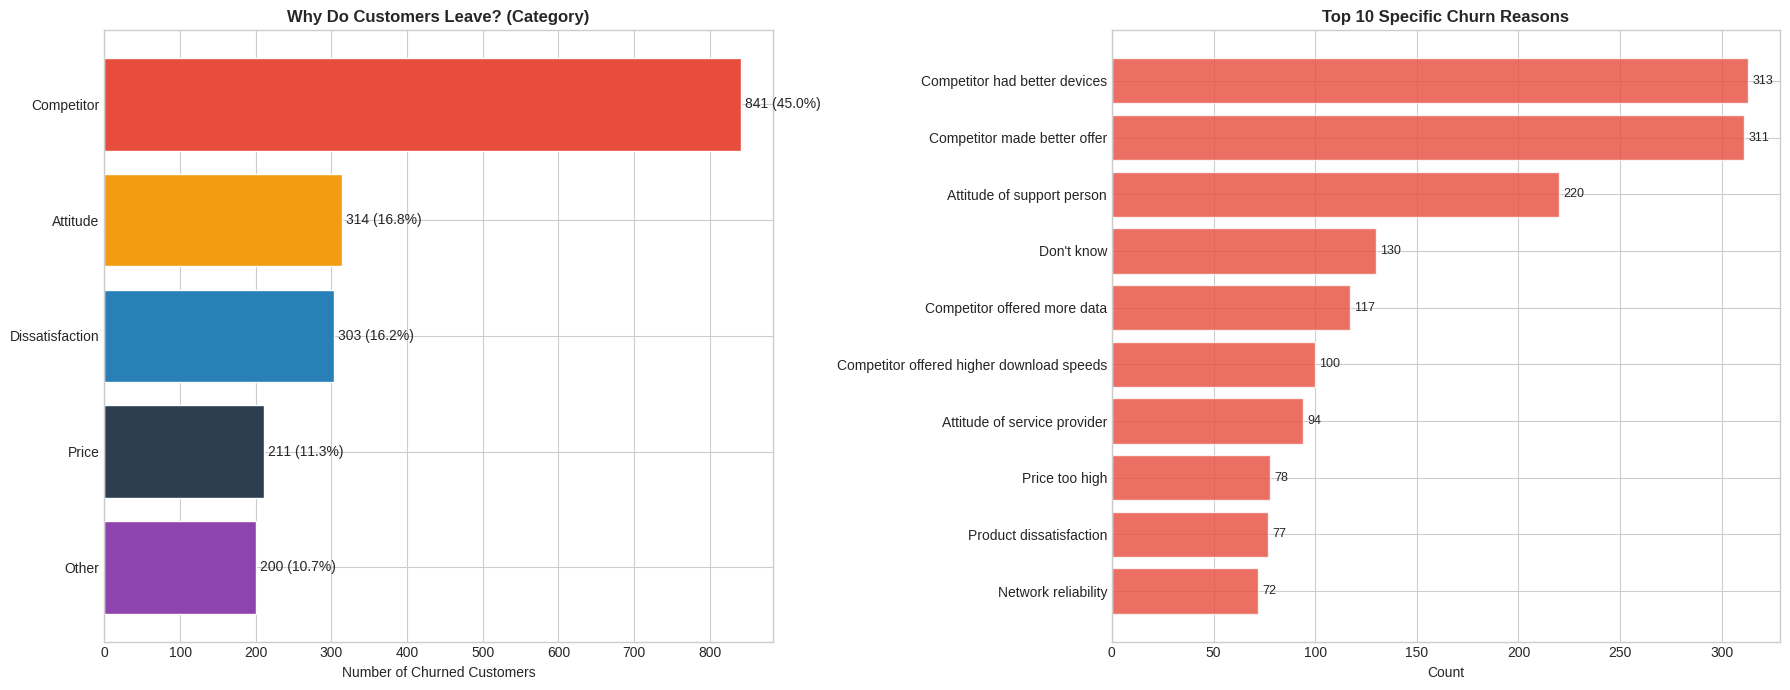


Churn Category Breakdown:
  Competitor           :  841 (45.0%)
  Attitude             :  314 (16.8%)
  Dissatisfaction      :  303 (16.2%)
  Price                :  211 (11.3%)
  Other                :  200 (10.7%)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CHURN REASON ANALYSIS
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Churn Category (high-level) ──
cat_counts = churned_df['churn_category'].value_counts()
cat_counts = cat_counts[cat_counts.index != 'Not Applicable']
colors_cat = [COLORS['churn'], COLORS['warning'], COLORS['neutral'],
              COLORS['dark'], COLORS['joined']][:len(cat_counts)]
bars = axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                    color=colors_cat[::-1], edgecolor='white')
axes[0].set_title('Why Do Customers Leave? (Category)', fontweight='bold')
axes[0].set_xlabel('Number of Churned Customers')
for bar, val in zip(bars, cat_counts.values[::-1]):
    axes[0].text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                 f'{val} ({val/churned_df.shape[0]*100:.1f}%)',
                 va='center', fontsize=10)

# ── Top 10 Churn Reasons (granular) ──
reason_counts = churned_df['churn_reason'].value_counts().head(10)
reason_counts = reason_counts[reason_counts.index != 'Not Applicable']
bars = axes[1].barh(reason_counts.index[::-1], reason_counts.values[::-1],
                    color=COLORS['churn'], edgecolor='white', alpha=0.8)
axes[1].set_title('Top 10 Specific Churn Reasons', fontweight='bold')
axes[1].set_xlabel('Count')
for bar, val in zip(bars, reason_counts.values[::-1]):
    axes[1].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/07_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChurn Category Breakdown:")
for cat, n in cat_counts.items():
    print(f"  {cat:20} : {n:>4} ({n/churned_df.shape[0]*100:.1f}%)")

---
# SECTION 5 — CUSTOMER SEGMENTATION & VALUE ANALYSIS
## Siapa yang harus diprioritaskan untuk retention?

> **FINDING:** Segmen **"High Value / High Risk"** berisi **1,947 pelanggan** dengan churn rate
> **57.9%** dan total revenue at risk **\$2,936,815**. Avg monthly charges mereka \$88.12 dengan
> satisfaction score hanya **2.6/5** — menandakan dissatisfaction yang kuat.
>
> Sebaliknya, segmen "High Value / Low Risk" (1,456 pelanggan) hanya memiliki churn rate 3.9%
> dan "Low Value / Low Risk" (1,590 pelanggan) hanya 2.2%.
>
> **Business Implication:** Tidak semua churn sama pentingnya. **\$1 yang dikeluarkan untuk retain
> pelanggan High Value / High Risk** memiliki ROI jauh lebih tinggi. Segmen ini harus mendapat
> dedicated retention treatment — mereka membayar tinggi (\$88/bulan) tapi satisfaction rendah (2.6/5).

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 5.1 CUSTOMER SEGMENTATION — Value × Risk Matrix
# ═══════════════════════════════════════════════════════════════

# ── Define Value Tier (based on monthly_charges) ──
value_median = df_master['monthly_charges'].median()
df_master['value_tier'] = np.where(
    df_master['monthly_charges'] >= value_median, 'High Value', 'Low Value'
)

# ── Define Risk Tier (composite score) ──
# Menggunakan variabel yang terbukti berkorelasi dengan churn
df_master['risk_score'] = 0

# Contract: month-to-month = highest risk
df_master.loc[df_master['contract']=='Month-to-Month', 'risk_score'] += 3

# Tenure: early tenure = higher risk
df_master.loc[df_master['tenure'] <= 12, 'risk_score'] += 2
df_master.loc[(df_master['tenure'] > 12) & (df_master['tenure'] <= 24), 'risk_score'] += 1

# No protection services = higher risk
df_master.loc[df_master['has_protection']==0, 'risk_score'] += 1

# Electronic check = higher risk
df_master.loc[df_master['payment_method']=='Electronic check', 'risk_score'] += 1

# Low satisfaction = higher risk
df_master.loc[df_master['satisfaction_score'] <= 2, 'risk_score'] += 2

# Internet type: Fiber optic = higher risk
df_master.loc[df_master['internet_type']=='Fiber Optic', 'risk_score'] += 1

risk_median = df_master['risk_score'].median()
df_master['risk_tier'] = np.where(
    df_master['risk_score'] >= risk_median, 'High Risk', 'Low Risk'
)

# ── 2×2 Matrix ──
df_master['segment_2x2'] = df_master['value_tier'] + ' / ' + df_master['risk_tier']

segment_summary = df_master.groupby('segment_2x2').agg(
    n_customers=('is_churned', 'count'),
    churn_rate=('is_churned', 'mean'),
    avg_monthly=('monthly_charges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    total_revenue=('total_revenue', 'sum')
).reset_index()
segment_summary['churn_pct'] = (segment_summary['churn_rate'] * 100).round(1)
segment_summary['revenue_at_risk'] = (
    segment_summary['total_revenue'] * segment_summary['churn_rate']
).round(0)

print("=== 2×2 SEGMENT ANALYSIS ===")
display(segment_summary.style.background_gradient(
    cmap='RdYlGn_r', subset=['churn_pct']
).format({'churn_rate': '{:.1%}', 'avg_monthly': '${:.0f}',
          'total_revenue': '${:,.0f}', 'revenue_at_risk': '${:,.0f}'}))

=== 2×2 SEGMENT ANALYSIS ===


,segment_2x2,n_customers,churn_rate,avg_monthly,avg_tenure,avg_satisfaction,total_revenue,churn_pct,revenue_at_risk
0,High Value / High Risk,1947,57.9%,$88,21.970211,2.597329,"$5,073,629",57.900000,"$2,936,815"
1,High Value / Low Risk,1577,7.0%,$94,55.951173,3.552315,"$10,610,925",7.000000,"$746,869"
2,Low Value / High Risk,1671,34.9%,$41,10.816876,3.131059,"$1,106,908",34.900000,"$386,192"
3,Low Value / Low Risk,1848,2.6%,$37,42.696970,3.767857,"$4,579,671",2.600000,"$118,952"


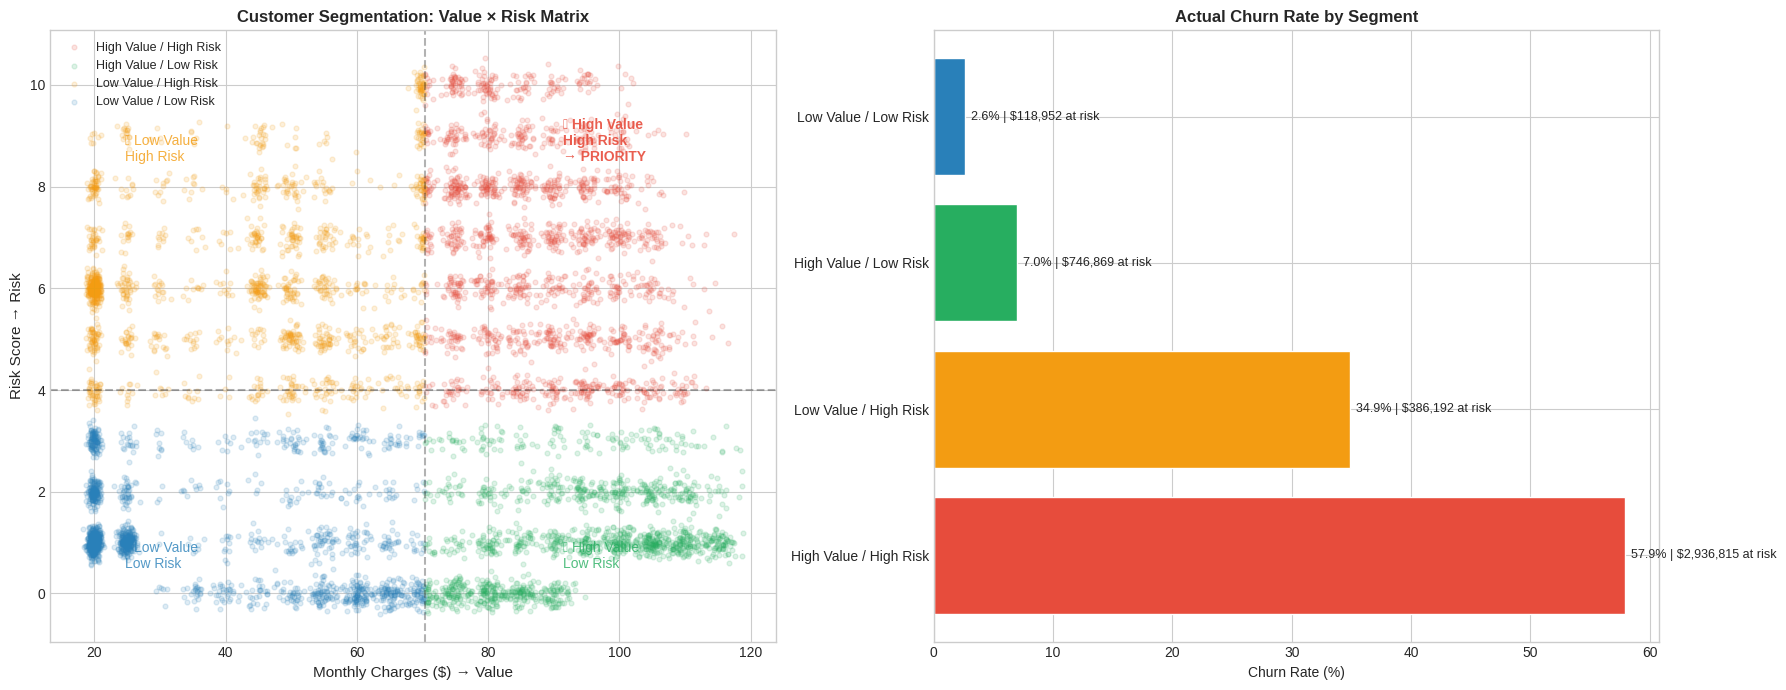


🔥 PRIORITY SEGMENT: High Value / High Risk
   Count              : 1,947 customers
   Churn rate         : 57.9%
   Total revenue      : $5,073,629
   Revenue at risk    : $2,936,815
   Avg monthly charges: $88.12
   Avg satisfaction   : 2.6/5


In [ ]:
# ── Segmentation Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_seg = {
    'High Value / High Risk': COLORS['churn'],
    'High Value / Low Risk': COLORS['retain'],
    'Low Value / High Risk': COLORS['warning'],
    'Low Value / Low Risk': COLORS['neutral']
}

# ── Scatter plot ──
for seg, group in df_master.groupby('segment_2x2'):
    jitter = np.random.normal(0, 0.15, len(group))
    axes[0].scatter(group['monthly_charges'],
                    group['risk_score'] + jitter,
                    alpha=0.15, label=seg, color=colors_seg.get(seg, 'gray'), s=12)
axes[0].axvline(x=value_median, color='black', linestyle='--', alpha=0.3)
axes[0].axhline(y=risk_median, color='black', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Monthly Charges ($) → Value', fontsize=11)
axes[0].set_ylabel('Risk Score → Risk', fontsize=11)
axes[0].set_title('Customer Segmentation: Value × Risk Matrix', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')

# Quadrant labels
axes[0].text(value_median*0.35, df_master['risk_score'].max()*0.85,
             '⚠ Low Value\nHigh Risk', fontsize=10, color=COLORS['warning'], alpha=0.8)
axes[0].text(value_median*1.3, df_master['risk_score'].max()*0.85,
             '🔥 High Value\nHigh Risk\n→ PRIORITY', fontsize=10,
             color=COLORS['churn'], fontweight='bold', alpha=0.9)
axes[0].text(value_median*1.3, 0.5,
             '✓ High Value\nLow Risk', fontsize=10, color=COLORS['retain'], alpha=0.8)
axes[0].text(value_median*0.35, 0.5,
             '💤 Low Value\nLow Risk', fontsize=10, color=COLORS['neutral'], alpha=0.8)

# ── Segment churn rate bar ──
seg_order = ['High Value / High Risk', 'Low Value / High Risk',
             'High Value / Low Risk', 'Low Value / Low Risk']
seg_order = [s for s in seg_order if s in segment_summary['segment_2x2'].values]
seg_plot = segment_summary.set_index('segment_2x2').loc[seg_order]
bars = axes[1].barh(range(len(seg_plot)), seg_plot['churn_pct'],
                    color=[colors_seg[s] for s in seg_order], edgecolor='white')
axes[1].set_yticks(range(len(seg_plot)))
axes[1].set_yticklabels(seg_order, fontsize=10)
axes[1].set_title('Actual Churn Rate by Segment', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for bar, (_, row) in zip(bars, seg_plot.iterrows()):
    axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{row["churn_pct"]:.1f}% | ${row["revenue_at_risk"]:,.0f} at risk',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/08_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Priority segment detail ──
hv_hr = df_master[df_master['segment_2x2']=='High Value / High Risk']
print(f"\n🔥 PRIORITY SEGMENT: High Value / High Risk")
print(f"   Count              : {len(hv_hr):,} customers")
print(f"   Churn rate         : {hv_hr['is_churned'].mean()*100:.1f}%")
print(f"   Total revenue      : ${hv_hr['total_revenue'].sum():,.0f}")
print(f"   Revenue at risk    : ${hv_hr['total_revenue'].sum() * hv_hr['is_churned'].mean():,.0f}")
print(f"   Avg monthly charges: ${hv_hr['monthly_charges'].mean():.2f}")
print(f"   Avg satisfaction   : {hv_hr['satisfaction_score'].mean():.1f}/5")

---
# SECTION 6 — CHURN RISK PROFILING & EARLY WARNING

> **FINDING:** Risk scoring model berhasil membedakan pelanggan dengan sangat baik
> (point-biserial r = **0.657**, p ≈ 0 — **good discriminator**):
>
> | Risk Label | N | Actual Churn | Avg Monthly | Avg Satisfaction | Revenue at Risk |
> |------------|------|-------------|-------------|-----------------|-----------------|
> | Low Risk | 3,010 | **2.9%** | \$63.80 | 3.7/5 | \$406,152 |
> | Medium Risk | 887 | **15.6%** | \$64.47 | 3.5/5 | \$431,641 |
> | High Risk | 1,458 | **19.8%** | \$58.05 | 3.6/5 | \$523,046 |
> | Critical | 1,688 | **80.3%** | \$72.43 | 2.1/5 | \$1,523,820 |
>
> Pelanggan "Critical" memiliki churn rate **80.3%** — hampir pasti churn. Satisfaction score
> mereka hanya 2.1/5, jauh di bawah rata-rata. Revenue at risk terbesar (\$1.5M) ada di segmen ini.
>
> **Business Implication:** Risk score ini bisa diimplementasikan sebagai automated early warning
> system. Pelanggan yang memasuki tier "Critical" perlu immediate intervention.

=== RISK SCORING EVALUATION ===


,risk_label,n,actual_churn_rate,avg_monthly,avg_satisfaction,total_rev,churn_pct,rev_at_risk
0,Low Risk,3010,0.03,63.80,3.70,14051915.33,2.90,406152.00
1,Medium Risk,887,0.16,64.47,3.47,2774388.59,15.60,431641.00
2,High Risk,1458,0.20,58.05,3.56,2647918.89,19.80,523046.00
3,Critical,1688,0.80,72.43,2.05,1896908.88,80.30,1523820.00


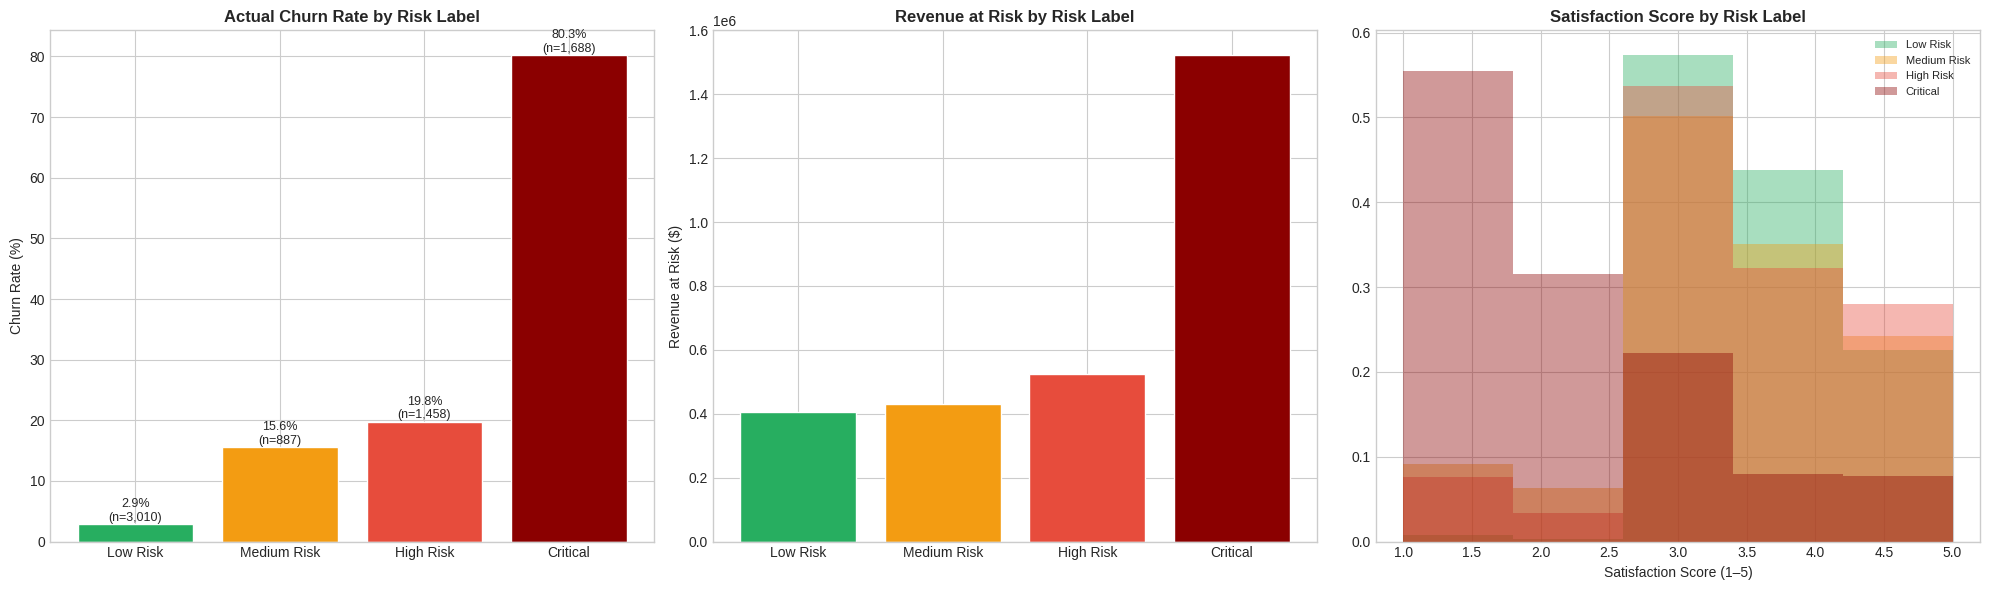


Risk Score Validation:
  Point-biserial r = 0.657 (p = 0.00e+00)
  ✓ Good discriminator


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 6.1 RISK SCORING EVALUATION
# ═══════════════════════════════════════════════════════════════

df_master['risk_label'] = pd.cut(
    df_master['risk_score'],
    bins=[-1, 2, 4, 6, 999],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
)

risk_eval = df_master.groupby('risk_label', observed=False).agg(
    n=('is_churned', 'count'),
    actual_churn_rate=('is_churned', 'mean'),
    avg_monthly=('monthly_charges', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    total_rev=('total_revenue', 'sum')
).reset_index()
risk_eval['churn_pct'] = (risk_eval['actual_churn_rate'] * 100).round(1)
risk_eval['rev_at_risk'] = (risk_eval['total_rev'] * risk_eval['actual_churn_rate']).round(0)

print("=== RISK SCORING EVALUATION ===")
display(risk_eval)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Churn rate by risk label ──
risk_colors = [COLORS['retain'], COLORS['warning'], COLORS['churn'], '#8B0000']
bars = axes[0].bar(risk_eval['risk_label'], risk_eval['churn_pct'],
                   color=risk_colors[:len(risk_eval)], edgecolor='white')
axes[0].set_title('Actual Churn Rate by Risk Label', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for bar, (_, row) in zip(bars, risk_eval.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{row["churn_pct"]:.1f}%\n(n={row["n"]:,})',
                 ha='center', fontsize=9)

# ── Revenue at risk ──
axes[1].bar(risk_eval['risk_label'], risk_eval['rev_at_risk'],
            color=risk_colors[:len(risk_eval)], edgecolor='white')
axes[1].set_title('Revenue at Risk by Risk Label', fontweight='bold')
axes[1].set_ylabel('Revenue at Risk ($)')

# ── Satisfaction distribution by risk ──
for rl, color in zip(['Low Risk', 'Medium Risk', 'High Risk', 'Critical'], risk_colors):
    subset = df_master[df_master['risk_label']==rl]['satisfaction_score']
    if len(subset) > 0:
        axes[2].hist(subset, bins=5, alpha=0.4, color=color, label=rl, density=True)
axes[2].set_title('Satisfaction Score by Risk Label', fontweight='bold')
axes[2].set_xlabel('Satisfaction Score (1–5)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/09_risk_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Validate risk score ──
r_pb, p_pb = pointbiserialr(df_master['risk_score'], df_master['is_churned'])
print(f"\nRisk Score Validation:")
print(f"  Point-biserial r = {r_pb:.3f} (p = {p_pb:.2e})")
print(f"  {'✓ Good discriminator' if abs(r_pb) > 0.3 else '○ Moderate discriminator'}")

---
# SECTION 7 — SYNTHESIS & RECOMMENDATIONS
## Framework: Pyramid Principle — Full Structure

---

## LEVEL 1 — BOTTOM LINE (untuk Executive):

> **26.5% pelanggan churn (1,869 dari 7,043), mengakibatkan revenue leakage $3.68M (17.2% total revenue).**
>
> **Semua 5 hipotesis terkonfirmasi.** Tiga intervensi prioritas berdasarkan data:
> 1. **Migrasi kontrak** — Month-to-Month → tahunan (churn drops dari 45.8% ke 6.2%)
> 2. **Service bundling** — TechSupport + OnlineSecurity untuk Fiber Optic (churn 40.7% → target <25%)
> 3. **Onboarding redesign** — fokus 12 bulan pertama (churn 47.4% di early tenure)

---

## LEVEL 2 — SUPPORTING ARGUMENTS (MECE):

### A. Churn didorong oleh kurangnya commitment kontrak (H1 ✓, H5 ✓)
- Month-to-Month churn rate **45.8%** vs yearly **6.2%** — rasio **7.4×** (χ² = 1414, p ≈ 0)
- Electronic check users: churn **45.3%** vs auto-payment **16.0%**
- **Implikasi:** Incentivize contract commitment + auto-payment migration

### B. Service adoption adalah "moat" terhadap churn (H2 ✓, H4 ✓)
- Tanpa TechSupport: churn **31.2%** vs dengan: **15.2%** (Δ = 16pp)
- Tanpa OnlineSecurity: churn **31.3%** vs dengan: **14.6%** (Δ = 16.7pp)
- **Fiber Optic paradox:** charges tertinggi + churn tertinggi (**40.7%**) — value gap
- Setiap tambahan service → churn rate turun
- **Implikasi:** Value-added services = retention tools, bukan cost center

### C. Early lifecycle adalah periode paling kritis (H3 ✓)
- **47.4%** churn di ≤12 bulan pertama vs **17.1%** setelahnya (rasio 2.8×)
- Survival curve: drop paling tajam di bulan 1–6
- **Implikasi:** ROI tertinggi di onboarding, bukan winback

### D. Satisfaction & Competitor adalah root causes utama
- **Satisfaction score** = prediktor #1 (r = −0.755 dengan churn)
- Churn category terbesar: **Competitor (45.0%)**, Attitude (16.8%), Dissatisfaction (16.2%)
- Segmen Critical (risk score tinggi): satisfaction hanya **2.1/5**, churn rate **80.3%**
- **Implikasi:** Monitoring satisfaction + competitive pricing analysis

### E. High-value customers justru lebih rentan
- Churned customers membayar avg **\$74.44/bulan** vs retained **\$61.27/bulan**
- Segmen "High Value / High Risk": **1,947 pelanggan**, churn **57.9%**, revenue at risk **\$2.94M**
- **Implikasi:** Dedicated retention untuk high-value segment

---

## LEVEL 3 — EVIDENCE TABLE:

| Finding | Metric | Section | Statistical Test |
|---------|--------|---------|-----------------|
| Overall churn rate | **26.5%** (1,869/7,043) | Sec 4.1 | — |
| MTM vs yearly ratio | **7.4×** (45.8% vs 6.2%) | Sec 4.5 | Chi-square (χ²=1414, p≈0) |
| TechSupport impact | **−16.0pp** (31.2% → 15.2%) | Sec 4.4 | Chi-square (χ²=190, p=2.9e-43) |
| OnlineSecurity impact | **−16.7pp** (31.3% → 14.6%) | Sec 4.4 | Chi-square (χ²=206, p=1.2e-46) |
| Fiber Optic churn | **40.7%** (highest) | Sec 4.4 | — |
| Early tenure churn | **47.4%** (≤12mo) vs 17.1% | Sec 4.2 | Chi-square (χ²=709, p=3.7e-156) |
| E-check vs auto-pay | **45.3%** vs 16.0% | Sec 4.5 | — |
| Revenue lost | **$3,684,460** (17.2%) | Sec 4.3 | Mann-Whitney (p=3.3e-54) |
| Top churn reason | **Competitor (45.0%)** | Sec 4.7 | — |
| Satisfaction correlation | **r = −0.755** | Sec 4.6 | Point-biserial |
| Risk score validation | **r = 0.657** | Sec 6 | Point-biserial (p≈0) |
| High Value/High Risk | **1,947 customers, 57.9% churn** | Sec 5 | — |

---

## ACTION PLAN:

### 🟢 QUICK WIN (0–30 hari): Contract Migration Campaign
- **Target:** 3,610 pelanggan Month-to-Month (terutama tenure > 6 bulan)
- **Tactic:** Diskon 10–15% untuk switch ke One Year contract + auto-payment setup
- **Expected impact:** Jika 20% migrasi → reduce ~330 churns → save ~$650K revenue/tahun
- **Monitoring:** Conversion rate + churn rate post-migration

### 🟡 MID-TERM (1–3 bulan): Fiber Optic Service Bundle
- **Insight:** 3,035 Fiber Optic customers, churn rate 40.7% — highest di semua internet type
- **Tactic:** Bundle TechSupport + OnlineSecurity gratis 3 bulan pertama (Δ churn ~16pp per service)
- **Expected impact:** Reduce Fiber churn dari 40.7% ke target <25%
- **Monitoring:** Fiber churn rate + satisfaction score pre/post

### 🔴 LONG-TERM (3–6 bulan): Onboarding Redesign + Satisfaction Monitoring
- **Insight:** 47.4% churn di ≤12 bulan pertama; satisfaction score = prediktor #1 (r = −0.755)
- **Tactic:** Automated check-in di bulan 1, 3, 6, 12 + satisfaction survey trigger
- **Expected impact:** Reduce early-tenure churn rate 10–15pp
- **Monitoring:** Early tenure churn rate + satisfaction trend + risk score distribution

### 🟣 STRATEGIC: Implement Risk Scoring System
- **Insight:** Risk score r = 0.657 — good discriminator. "Critical" tier: 80.3% churn
- **Tactic:** Automate risk scoring → flag customers entering "Critical" tier → trigger retention playbook
- **Expected impact:** Proactive intervention untuk 1,688 Critical customers → save portion of $1.52M at risk

---

## LIMITATIONS & NEXT STEPS:
1. **Descriptive, bukan predictive** — untuk individual churn scoring, perlu ML model (Logistic Regression / XGBoost / Random Forest)
2. **Korelasi ≠ kausalitas** — perlu A/B testing untuk validasi efektivitas intervensi
3. **Data cross-sectional** — tidak ada time-series untuk melihat trend churn over time
4. **Single state (California)** — generalisasi ke market lain perlu validasi
5. **`churn_score` sudah tersedia di dataset** — bisa dibandingkan dengan risk score buatan kita (r = 0.657 vs churn_score r = 0.661)
6. **Next project:** Predictive model → Power BI dashboard → Streamlit app interaktif

---
# SECTION 8 — EXPORT UNTUK POWER BI

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 8.1 EXPORT FILES
# ═══════════════════════════════════════════════════════════════

os.makedirs('data/powerbi', exist_ok=True)

# 1. Master table — semua kolom termasuk derived features
df_master.to_csv('data/powerbi/master_churn.csv', index=False)
print(f"✓ master_churn.csv: {df_master.shape[1]} cols, {len(df_master):,} rows")

# 2. KPI Summary
kpi = {
    'total_customers': int(len(df_master)),
    'churned': int(df_master['is_churned'].sum()),
    'stayed': int((df_master['customer_status']=='Stayed').sum()),
    'joined': int((df_master['customer_status']=='Joined').sum()),
    'churn_rate_pct': round(float(df_master['is_churned'].mean()*100), 2),
    'total_revenue': round(float(df_master['total_revenue'].sum()), 2),
    'revenue_lost': round(float(churned_df['total_revenue'].sum()), 2),
    'avg_monthly_churned': round(float(churned_df['monthly_charges'].mean()), 2),
    'avg_monthly_retained': round(float(retained_df['monthly_charges'].mean()), 2),
    'avg_satisfaction_churned': round(float(churned_df['satisfaction_score'].mean()), 2),
    'avg_satisfaction_retained': round(float(retained_df['satisfaction_score'].mean()), 2),
}
pd.DataFrame([kpi]).to_csv('data/powerbi/kpi_summary.csv', index=False)
print("✓ kpi_summary.csv")

# 3. Segment summary
segment_summary.to_csv('data/powerbi/segment_summary.csv', index=False)
print("✓ segment_summary.csv")

# 4. Risk evaluation
risk_eval.to_csv('data/powerbi/risk_evaluation.csv', index=False)
print("✓ risk_evaluation.csv")

# 5. Churn reasons summary
churn_reasons = churned_df['churn_category'].value_counts().reset_index()
churn_reasons.columns = ['category', 'count']
churn_reasons.to_csv('data/powerbi/churn_reasons.csv', index=False)
print("✓ churn_reasons.csv")

# 6. Metadata JSON
metadata = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d'),
    'dataset': 'IBM Telco Customer Churn (hassanelfattmi/Kaggle)',
    'tables_merged': list(tables.keys()),
    'kpi': kpi,
    'hypotheses': {
        'H1_contract': f'MTM ≥ 2x yearly — {"CONFIRMED" if confirmed_h1 else "NOT CONFIRMED"}',
        'H2_services': f'TechSupport reduces churn — {"CONFIRMED" if confirmed_h2 else "NOT CONFIRMED"}',
        'H3_tenure': f'Early tenure = high churn — {"CONFIRMED" if confirmed_h3 else "NOT CONFIRMED"}',
        'H4_fiber': f'Fiber > DSL churn — {"CONFIRMED" if confirmed_h4 else "NOT CONFIRMED"}',
        'H5_payment': f'E-check > auto-pay — {"CONFIRMED" if confirmed_h5 else "NOT CONFIRMED"}',
    },
    'top_correlates': {k: round(float(v), 4) for k, v in corr_with_churn.head(5).items()}
}
with open('data/powerbi/analysis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ analysis_metadata.json")

print(f"\n{'═'*50}")
print("  NOTEBOOK COMPLETE ✓")
print(f"{'═'*50}")
print(f"  Exported to: data/powerbi/")
print(f"  Files: master_churn.csv, kpi_summary.csv, segment_summary.csv,")
print(f"         risk_evaluation.csv, churn_reasons.csv, analysis_metadata.json")
print(f"  Charts: outputs/*.png")
print(f"\n  Ready for: Power BI import | Streamlit app | LinkedIn post")

✓ master_churn.csv: 65 cols, 7,043 rows
✓ kpi_summary.csv
✓ segment_summary.csv
✓ risk_evaluation.csv
✓ churn_reasons.csv
✓ analysis_metadata.json

══════════════════════════════════════════════════
  NOTEBOOK COMPLETE ✓
══════════════════════════════════════════════════
  Exported to: data/powerbi/
  Files: master_churn.csv, kpi_summary.csv, segment_summary.csv,
         risk_evaluation.csv, churn_reasons.csv, analysis_metadata.json
  Charts: outputs/*.png

  Ready for: Power BI import | Streamlit app | LinkedIn post
